# Prédiction de Trafic — Analyse Complète et Modélisation Rigoureuse

**Objectifs :**
- Analyse exploratoire exhaustive du dataset de trafic
- Split temporel rigoureux **SANS data leakage**
- 3 paradigmes de modélisation comparés équitablement
  - **P1** : Modèle LSTM Global (entraîné sur toutes les jonctions)
  - **P2** : Modèles LSTM Spécifiques (un par jonction)
  - **P3** : Modèle GNN (exploite les relations entre jonctions)
- Courbes d'apprentissage, métriques détaillées, visualisations
- Évaluation sur un ensemble de test commun et strictement isolé

In [1]:
# ============================================================
# 1. IMPORTS ET CONFIGURATION
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from copy import deepcopy

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn (uniquement pour les métriques et preprocessing SANS leakage)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Visualisation
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositif : {DEVICE}")

Dispositif : cuda


In [2]:
# ============================================================
# 2. CHARGEMENT DU DATASET
# ============================================================
import kagglehub

path = kagglehub.dataset_download("fedesoriano/traffic-prediction-dataset")
print(f"Dataset path : {path}")

df_raw = pd.read_csv(f'{path}/traffic.csv')
df_raw['DateTime'] = pd.to_datetime(df_raw['DateTime'])
df_raw = df_raw.set_index('DateTime').sort_index()

print(f"Dimensions : {df_raw.shape}")
display(df_raw.head())

100%|██████████| 277k/277k [00:00<00:00, 658kB/s]

Extracting files...
Dataset path : /root/.cache/kagglehub/datasets/fedesoriano/traffic-prediction-dataset/versions/1
Dimensions : (48120, 3)


,Junction,Vehicles,ID
DateTime,,,
2015-11-01 00:00:00,1,15,20151101001
2015-11-01 00:00:00,2,6,20151101002
2015-11-01 00:00:00,3,9,20151101003
2015-11-01 01:00:00,3,7,20151101013
2015-11-01 01:00:00,1,13,20151101011


---
## 3. Analyse Exploratoire des Données (EDA)

**Objectif :** Comprendre la structure, les distributions, les périodes de collecte par jonction, et les patterns temporels AVANT toute modélisation.

In [3]:
# ============================================================
# 3a. Statistiques générales et valeurs manquantes
# ============================================================
print("--- VALEURS MANQUANTES ---")
print(df_raw.isnull().sum())
print()

print("--- STATISTIQUES DESCRIPTIVES ---")
display(df_raw.describe())
print()

print("--- TYPES DE DONNÉES ---")
print(df_raw.dtypes)

--- VALEURS MANQUANTES ---
Junction    0
Vehicles    0
ID          0
dtype: int64

--- STATISTIQUES DESCRIPTIVES ---


,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10



--- TYPES DE DONNÉES ---
Junction    int64
Vehicles    int64
ID          int64
dtype: object


In [4]:
# ============================================================
# 3b. Analyse temporelle par jonction
# ============================================================
print("--- PÉRIODES DE COLLECTE PAR JONCTION ---")
for j in sorted(df_raw['Junction'].unique()):
    df_j = df_raw[df_raw['Junction'] == j]
    print(f"Jonction {j} : {df_j.index.min()} → {df_j.index.max()}  ({len(df_j)} enregistrements)")

print()
print("--- HEURES MANQUANTES PAR JONCTION ---")
for j in sorted(df_raw['Junction'].unique()):
    df_j = df_raw[df_raw['Junction'] == j]
    full_range = pd.date_range(df_j.index.min(), df_j.index.max(), freq='h')
    missing = full_range.difference(df_j.index)
    print(f"Jonction {j} : {len(missing)} heures manquantes sur {len(full_range)} attendues ({100*len(missing)/len(full_range):.1f}%)")

--- PÉRIODES DE COLLECTE PAR JONCTION ---
Jonction 1 : 2015-11-01 00:00:00 → 2017-06-30 23:00:00  (14592 enregistrements)
Jonction 2 : 2015-11-01 00:00:00 → 2017-06-30 23:00:00  (14592 enregistrements)
Jonction 3 : 2015-11-01 00:00:00 → 2017-06-30 23:00:00  (14592 enregistrements)
Jonction 4 : 2017-01-01 00:00:00 → 2017-06-30 23:00:00  (4344 enregistrements)

--- HEURES MANQUANTES PAR JONCTION ---
Jonction 1 : 0 heures manquantes sur 14592 attendues (0.0%)
Jonction 2 : 0 heures manquantes sur 14592 attendues (0.0%)
Jonction 3 : 0 heures manquantes sur 14592 attendues (0.0%)
Jonction 4 : 0 heures manquantes sur 4344 attendues (0.0%)


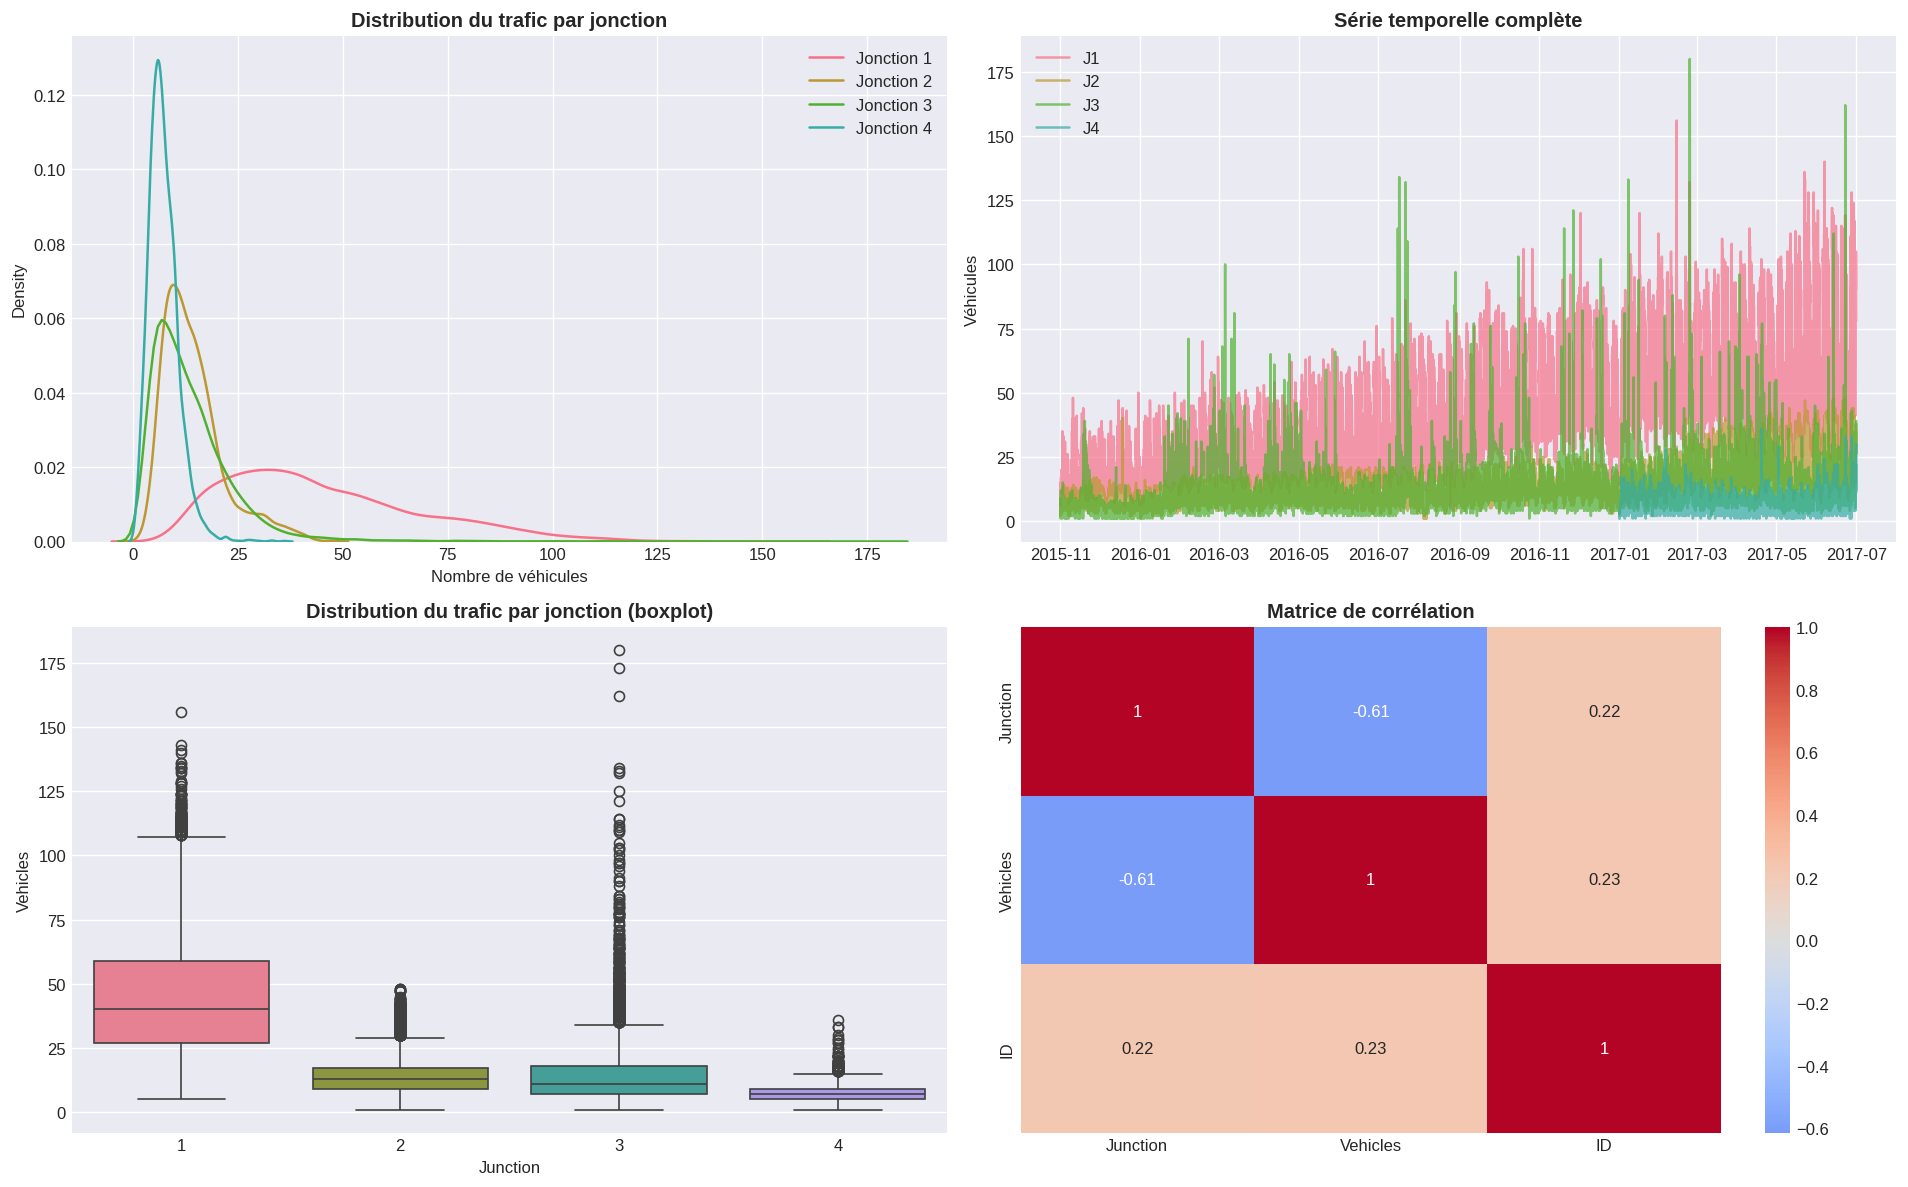

In [5]:
# ============================================================
# 3c. Visualisation EDA
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribution des véhicules
ax = axes[0, 0]
for j in sorted(df_raw['Junction'].unique()):
    sns.kdeplot(df_raw[df_raw['Junction']==j]['Vehicles'], label=f'Jonction {j}', ax=ax)
ax.set_title('Distribution du trafic par jonction', fontweight='bold')
ax.set_xlabel('Nombre de véhicules')
ax.legend()

# Série temporelle complète
ax = axes[0, 1]
for j in sorted(df_raw['Junction'].unique()):
    df_j = df_raw[df_raw['Junction']==j]
    ax.plot(df_j.index, df_j['Vehicles'], label=f'J{j}', alpha=0.7)
ax.set_title('Série temporelle complète', fontweight='bold')
ax.set_ylabel('Véhicules')
ax.legend()

# Boîte à moustaches par jonction
ax = axes[1, 0]
sns.boxplot(data=df_raw, x='Junction', y='Vehicles', ax=ax, palette='husl')
ax.set_title('Distribution du trafic par jonction (boxplot)', fontweight='bold')

# Heatmap de corrélation
ax = axes[1, 1]
numeric_df = df_raw.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 1:
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matrice de corrélation', fontweight='bold')

plt.tight_layout()
plt.show()

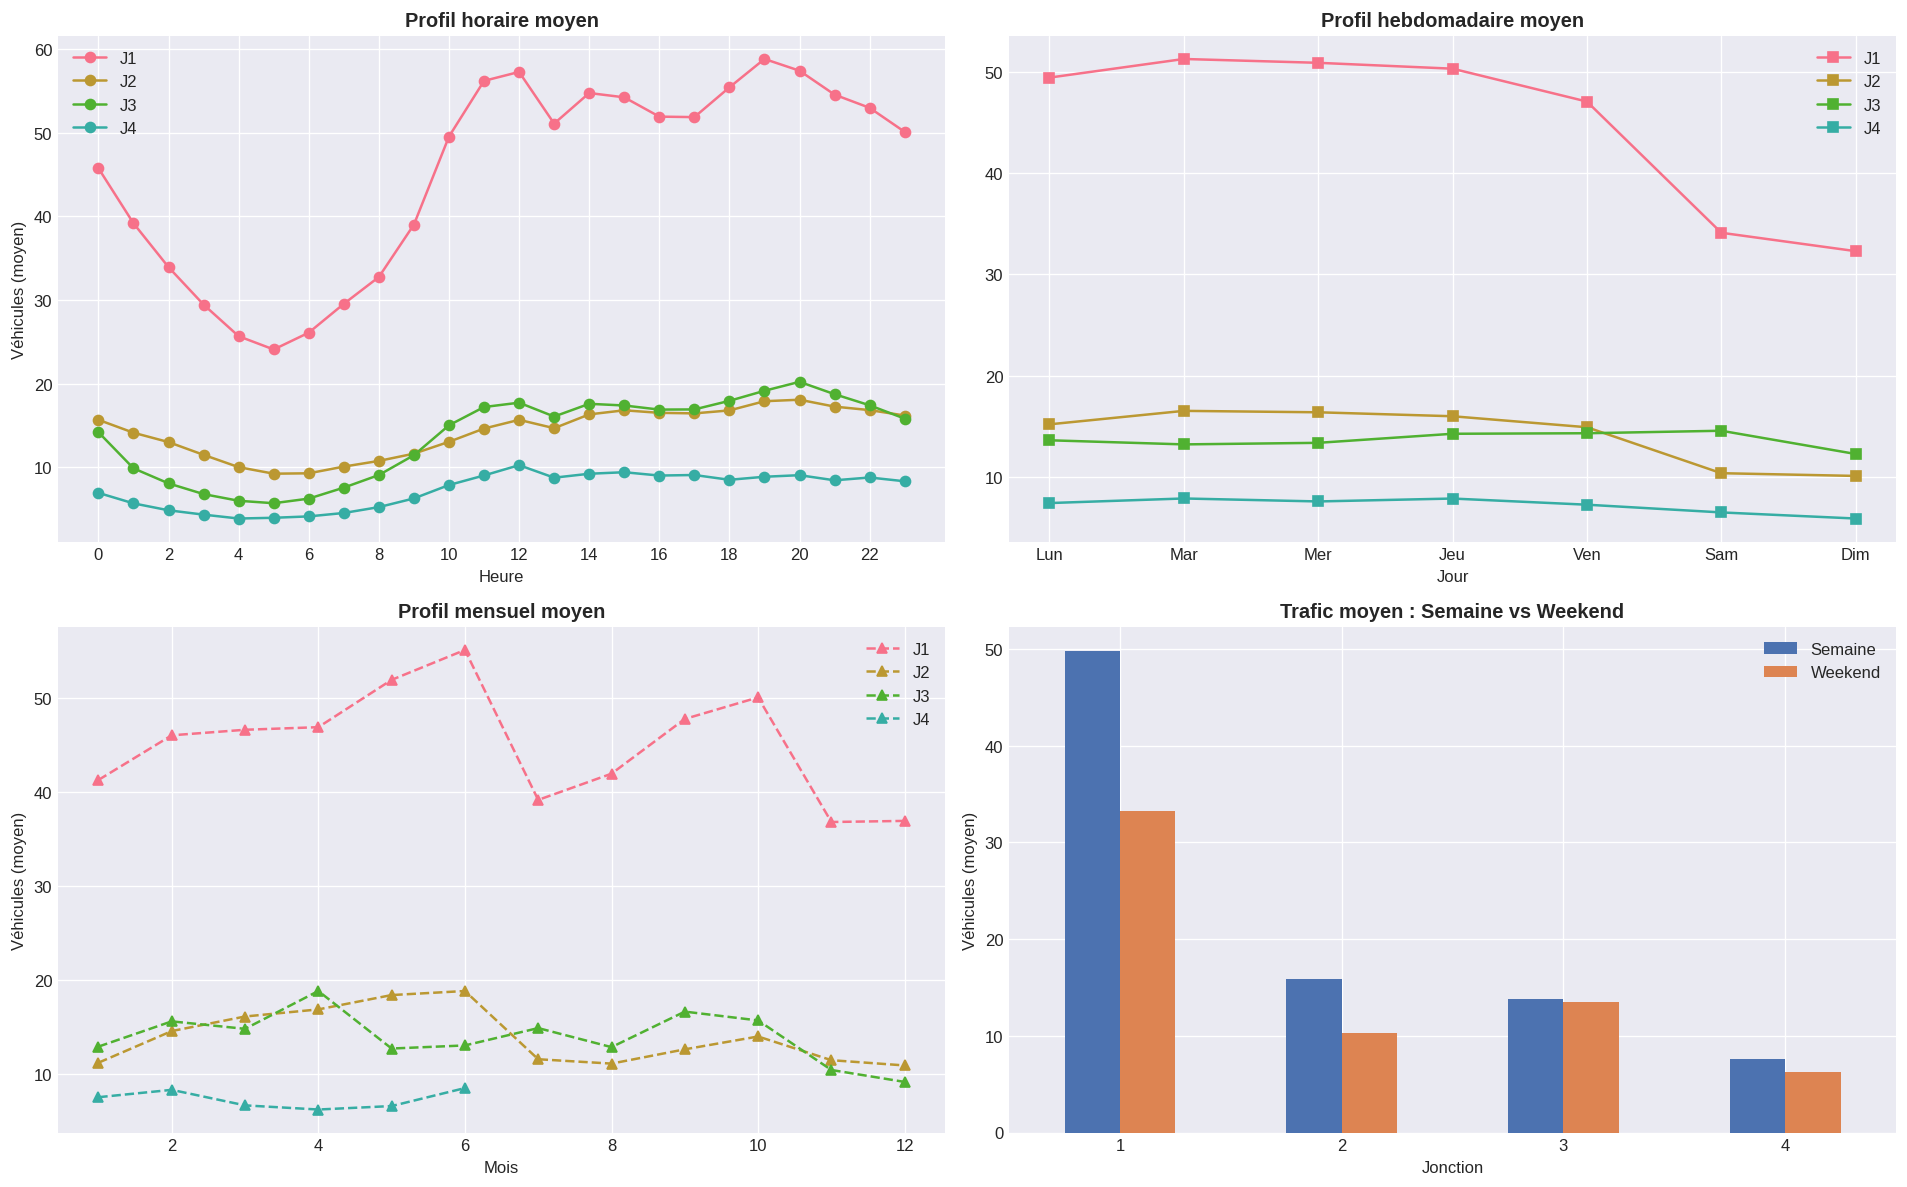

In [6]:
# ============================================================
# 3d. Analyse des patterns temporels
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Profil horaire moyen par jonction
ax = axes[0, 0]
for j in sorted(df_raw['Junction'].unique()):
    df_j = df_raw[df_raw['Junction']==j]
    hourly = df_j.groupby(df_j.index.hour)['Vehicles'].mean()
    ax.plot(hourly.index, hourly.values, 'o-', label=f'J{j}')
ax.set_title('Profil horaire moyen', fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Véhicules (moyen)')
ax.legend()
ax.set_xticks(range(0, 24, 2))

# Profil jour de semaine
ax = axes[0, 1]
days = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
for j in sorted(df_raw['Junction'].unique()):
    df_j = df_raw[df_raw['Junction']==j]
    dow = df_j.groupby(df_j.index.dayofweek)['Vehicles'].mean()
    ax.plot(dow.index, dow.values, 's-', label=f'J{j}')
ax.set_title('Profil hebdomadaire moyen', fontweight='bold')
ax.set_xlabel('Jour')
ax.set_xticks(range(7))
ax.set_xticklabels(days)
ax.legend()

# Profil mensuel
ax = axes[1, 0]
for j in sorted(df_raw['Junction'].unique()):
    df_j = df_raw[df_raw['Junction']==j]
    monthly = df_j.groupby(df_j.index.month)['Vehicles'].mean()
    ax.plot(monthly.index, monthly.values, '^--', label=f'J{j}')
ax.set_title('Profil mensuel moyen', fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Véhicules (moyen)')
ax.legend()

# Weekend vs semaine
ax = axes[1, 1]
df_raw['is_weekend'] = (df_raw.index.dayofweek >= 5).astype(int)
weekend_stats = df_raw.groupby(['Junction', 'is_weekend'])['Vehicles'].mean().unstack()
weekend_stats.columns = ['Semaine', 'Weekend']
weekend_stats.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Trafic moyen : Semaine vs Weekend', fontweight='bold')
ax.set_xlabel('Jonction')
ax.set_ylabel('Véhicules (moyen)')
ax.legend()
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 4. Préparation des Données — **ZÉRO DATA LEAKAGE**

### Problème du notebook original
Dans la version originale :
1. Les `lags` étaient créés sur le dataset COMPLET avant le split → information future dans les features d'entraînement
2. `StandardScaler.fit_transform()` était appelé sur toutes les données avant split → la moyenne/écart-type du test fuite dans l'entraînement
3. Les splits P1 (70/15/15) et P2 (80/20) étaient différents → comparaison impossible

### Solution : Split d'abord, feature engineering après
1. Split chronologique en train/val/test SUR LES DONNÉES BRUTES
2. Feature engineering (lags, features cycliques) séparément sur chaque split
3. `StandardScaler.fit()` UNIQUEMENT sur train, puis `transform()` sur val et test

In [7]:
# ============================================================
# 4a. Split temporel STRICT — avant toute transformation
# ============================================================
# On split d'abord les données BRUTES pour garantir zero leakage
data_len = len(df_raw)
train_end = int(data_len * 0.70)
val_end = int(data_len * 0.85)

df_train_raw = df_raw.iloc[:train_end].copy()
df_val_raw = df_raw.iloc[train_end:val_end].copy()
df_test_raw = df_raw.iloc[val_end:].copy()

print(f"Train : {df_train_raw.index.min()} → {df_train_raw.index.max()} ({len(df_train_raw)} enreg.)")
print(f"Val   : {df_val_raw.index.min()} → {df_val_raw.index.max()} ({len(df_val_raw)} enreg.)")
print(f"Test  : {df_test_raw.index.min()} → {df_test_raw.index.max()} ({len(df_test_raw)} enreg.)")
print(f"Split : {100*len(df_train_raw)/data_len:.0f}% / {100*len(df_val_raw)/data_len:.0f}% / {100*len(df_test_raw)/data_len:.0f}%")

Train : 2015-11-01 00:00:00 → 2017-01-31 14:00:00 (33684 enreg.)
Val   : 2017-01-31 15:00:00 → 2017-04-16 19:00:00 (7218 enreg.)
Test  : 2017-04-16 19:00:00 → 2017-06-30 23:00:00 (7218 enreg.)
Split : 70% / 15% / 15%


In [8]:
# ============================================================
# 4b. Feature engineering — SANS contamination temporelle
# ============================================================
def engineer_features(df, lags=[1, 2, 3, 24]):
    """
    Crée les features temporelles et les lags.
    """
    df = df.copy()

    # 1. Features temporelles cycliques
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

    # Encodage cyclique (crucial pour les séries temporelles)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7.0)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

    # 2. Lags temporels
    df = df.sort_index()
    for lag in lags:
        df[f'veh_lag_{lag}'] = df['Vehicles'].shift(lag)

    # 3. Moyennes mobiles (uniquement sur le passé)
    df['veh_ma_6'] = df['Vehicles'].shift(1).rolling(6, min_periods=1).mean()
    df['veh_ma_24'] = df['Vehicles'].shift(1).rolling(24, min_periods=1).mean()

    # 4. Différence horaire
    df['veh_diff_1'] = df['Vehicles'] - df['veh_lag_1']

    # Supprimer les NaN créés par les shifts
    df = df.dropna()

    return df

# Appliquer sur chaque split SÉPARÉMENT
df_train = engineer_features(df_train_raw)
df_val = engineer_features(df_val_raw)
df_test = engineer_features(df_test_raw)

# Vérification : aucune date en commun
print("Vérification d'étanchéité temporelle:")
print(f"  Train max : {df_train.index.max()}")
print(f"  Val min    : {df_val.index.min()}")
print(f"  Val max    : {df_val.index.max()}")
print(f"  Test min   : {df_test.index.min()}")
assert df_train.index.max() < df_val.index.min(), "TRAIN CONTAMINE VAL!"
assert df_val.index.max() < df_test.index.min(), "VAL CONTAMINE TEST!"
print("Aucune contamination temporelle entre les splits.")

Vérification d'étanchéité temporelle:
  Train max : 2017-01-31 14:00:00
  Val min    : 2017-01-31 21:00:00
  Val max    : 2017-04-16 19:00:00
  Test min   : 2017-04-17 01:00:00
Aucune contamination temporelle entre les splits.


In [9]:
# ============================================================
# 4c. Liste des features et scaling SANS leakage
# ============================================================
FEATURES = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_weekend',
    'veh_lag_1', 'veh_lag_2', 'veh_lag_3', 'veh_lag_24',
    'veh_ma_6', 'veh_ma_24', 'veh_diff_1'
]
TARGET = 'Vehicles'
SEQ_LENGTH = 24  # Fenêtre de 24h pour les séquences LSTM
BATCH_SIZE = 64

# On fit le scaler UNIQUEMENT sur train
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(df_train[FEATURES])
y_train_scaled = scaler_y.fit_transform(df_train[[TARGET]])

# Transform sur val et test (pas de fit !)
X_val_scaled = scaler_x.transform(df_val[FEATURES])
y_val_scaled = scaler_y.transform(df_val[[TARGET]])

X_test_scaled = scaler_x.transform(df_test[FEATURES])
y_test_scaled = scaler_y.transform(df_test[[TARGET]])

print(f"Features : {len(FEATURES)}")
print(f"Train : {len(df_train)} échantillons")
print(f"Val   : {len(df_val)} échantillons")
print(f"Test  : {len(df_test)} échantillons")

Features : 14
Train : 33660 échantillons
Val   : 7194 échantillons
Test  : 7194 échantillons


In [10]:
# ============================================================
# 4d. Création des séquences et DataLoaders
# ============================================================
def create_sequences(X, y, seq_length, batch_size, shuffle=False):
    """Crée des séquences glissantes pour le LSTM."""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])

    X_t = torch.tensor(np.array(X_seq), dtype=torch.float32)
    y_t = torch.tensor(np.array(y_seq), dtype=torch.float32)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader, (X_t, y_t)

# Création des loaders pour le MODELE GLOBAL (toutes jonctions confondues)
train_loader_g, (X_train_seq, y_train_seq) = create_sequences(
    X_train_scaled, y_train_scaled, SEQ_LENGTH, BATCH_SIZE, shuffle=True)
val_loader_g, (X_val_seq, y_val_seq) = create_sequences(
    X_val_scaled, y_val_scaled, SEQ_LENGTH, BATCH_SIZE, shuffle=False)
test_loader_g, (X_test_seq, y_test_seq) = create_sequences(
    X_test_scaled, y_test_scaled, SEQ_LENGTH, BATCH_SIZE, shuffle=False)

print(f"Séquences créées :")
print(f"  Train : {X_train_seq.shape[0]} séquences de {SEQ_LENGTH}h")
print(f"  Val   : {X_val_seq.shape[0]} séquences")
print(f"  Test  : {X_test_seq.shape[0]} séquences")

Séquences créées :
  Train : 33636 séquences de 24h
  Val   : 7170 séquences
  Test  : 7170 séquences


---
## 5. Définition des Modèles

In [11]:
# ============================================================
# 5a. Architecture LSTM (utilisée pour P1 et P2)
# ============================================================
class TrafficLSTM(nn.Module):
    """
    LSTM multicouche avec batch normalization et dropout.
    Utilisé pour les paradigmes Global (P1) et Spécifique (P2).
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.bn = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Dernier timestep seulement
        out = self.bn(out)
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [12]:
# ============================================================
# 5b. Architecture GNN (Paradigme 3)
# ============================================================
class TrafficGNN(nn.Module):
    """
    Modèle basé sur GNN (Graph Neural Network).

    Les 4 jonctions sont traitées comme un graphe où chaque jonction
    est un nœud. Le GNN propage l'information entre les jonctions
    pour capturer les dépendances spatiales.
    """
    def __init__(self, node_features, hidden_size=64):
        super().__init__()
        self.node_features = node_features
        self.hidden_size = hidden_size

        # Encodage LSTM local par nœud
        self.node_encoder = nn.LSTM(node_features, hidden_size, batch_first=True)

        # Propagation GCN (convolutions sur graphe)
        self.gcn_proj = nn.Linear(hidden_size, hidden_size)
        self.gcn_self = nn.Linear(hidden_size, hidden_size)

        # Attention entre jonctions
        self.attention = nn.MultiheadAttention(hidden_size, num_heads=2, batch_first=True)

        # Décodeur final par nœud
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x_nodes):
        """
        x_nodes : (B, N, S, F) — Batch, Noeuds, Sequences, Features
        """
        B, N, S, F = x_nodes.shape

        # 1. Encoder chaque nœud individuellement avec LSTM
        x_flat = x_nodes.view(B * N, S, F)
        encoded, _ = self.node_encoder(x_flat)
        encoded = encoded[:, -1, :].view(B, N, -1)  # (B, N, H)

        # 2. Propagation GCN (graphe fully connected)
        h = self.gcn_proj(encoded)
        agg = h.mean(dim=1, keepdim=True).expand(-1, N, -1)
        h_self = self.gcn_self(encoded)
        h_out = torch.relu(h_self + agg)

        # 3. Attention multi-tête entre nœuds
        attn_out, _ = self.attention(h_out, h_out, h_out)
        h_out = h_out + attn_out  # Connexion résiduelle

        # 4. Décodage par nœud
        out = self.decoder(h_out)  # (B, N, 1)
        return out

---
## 6. Boucle d'Entraînement Commune

In [13]:
# ============================================================
# 6a. Fonction d'entraînement avec suivi des métriques
# ============================================================
def train_model(model, train_loader, val_loader, criterion, optimizer,
                 epochs=50, device=DEVICE, model_name='Modèle',
                 patience=10):
    """
    Boucle d'entraînement avec early stopping et suivi de loss.
    """
    model = model.to(device)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_mae': [], 'val_mae': []
    }

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(epochs):
        # --- TRAIN ---
        model.train()
        train_loss, train_mae = 0.0, 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(bx)
            loss = criterion(pred, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            train_mae += torch.abs(pred - by).sum().item()

        # --- VAL ---
        model.eval()
        val_loss, val_mae = 0.0, 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                pred = model(bx)
                loss = criterion(pred, by)
                val_loss += loss.item()
                val_mae += torch.abs(pred - by).sum().item()

        # Moyennes
        n_train = len(train_loader.dataset)
        n_val = len(val_loader.dataset)
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_mae'].append(train_mae / n_train)
        history['val_mae'].append(val_mae / n_val)

        # Early Stopping
        avg_val_loss = val_loss / len(val_loader)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping à l'époque {epoch+1}")
                break

        # Log
        if (epoch + 1) % 5 == 0 or epoch == 0:
            tr_l = history['train_loss'][-1]
            vl_l = history['val_loss'][-1]
            tr_m = history['train_mae'][-1] * 100  # échelle lisible
            vl_m = history['val_mae'][-1] * 100
            print(f"  [{epoch+1:2d}/{epochs}]  Train loss: {tr_l:.5f}  Val loss: {vl_l:.5f}")

    # Restaurer le meilleur état
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"  Meilleure val_loss: {best_val_loss:.5f}")
    return model, history

In [14]:
# ============================================================
# 6b. Fonction d'évaluation standardisée
# ============================================================
def evaluate_model(model, test_loader, scaler_y, device=DEVICE):
    """
    Évalue le modèle sur le test set et retourne les métriques
    DANS L'ECHELLE ORIGINALE (dénormalisée).
    """
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(device)
            pred = model(bx)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(by.numpy())

    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    # Dénormaliser
    preds_real = scaler_y.inverse_transform(preds).flatten()
    targets_real = scaler_y.inverse_transform(targets).flatten()

    # Métriques
    mae = mean_absolute_error(targets_real, preds_real)
    rmse = np.sqrt(mean_squared_error(targets_real, preds_real))
    r2 = r2_score(targets_real, preds_real)
    mape = np.mean(np.abs((targets_real - preds_real) / (targets_real + 1e-8))) * 100

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}, targets_real, preds_real

---
## 7. Paradigme 1 : Modèle Global (P1)

Un seul modèle LSTM entraîné sur **toutes les jonctions confondues**. Il apprend les patterns généraux du trafic.

In [15]:
# ============================================================
# 7a. Entraînement du modèle Global
# ============================================================
model_global = TrafficLSTM(input_size=len(FEATURES))
criterion = nn.HuberLoss(delta=1.0)  # Robuste aux outliers
optimizer = optim.AdamW(model_global.parameters(), lr=1e-3, weight_decay=1e-5)

print("--- ENTRAINEMENT P1 : MODELE GLOBAL ---")
model_global, history_global = train_model(
    model_global, train_loader_g, val_loader_g,
    criterion, optimizer, epochs=50, model_name='P1 Global'
)

# Evaluation
metrics_p1, targets_p1, preds_p1 = evaluate_model(model_global, test_loader_g, scaler_y)
print(f"\n--- RESULTATS P1 (Global) ---")
for k, v in metrics_p1.items():
    print(f"  {k}: {v:.3f}")

--- ENTRAINEMENT P1 : MODELE GLOBAL ---
  [ 1/50]  Train loss: 0.29892  Val loss: 0.57664
  [ 5/50]  Train loss: 0.25410  Val loss: 0.55415
  [10/50]  Train loss: 0.22824  Val loss: 0.53105
  [15/50]  Train loss: 0.21705  Val loss: 0.51509
  [20/50]  Train loss: 0.20529  Val loss: 0.50989
  Early stopping à l'époque 21
  Meilleure val_loss: 0.50352

--- RESULTATS P1 (Global) ---
  MAE: 17.524
  RMSE: 24.073
  R2: 0.261
  MAPE: 122.540


In [16]:
# ============================================================
# 7b. Evaluation P1 par jonction
# ============================================================
def evaluate_by_junction(model, df_test, scaler_x, scaler_y, features, target):
    """Évalue le modèle global sur chaque jonction séparément."""
    model.eval()
    results = {}

    for j in sorted(df_test['Junction'].unique()):
        df_j = df_test[df_test['Junction'] == j].copy().sort_index()
        if len(df_j) < SEQ_LENGTH + 1:
            continue

        X_j = scaler_x.transform(df_j[features])
        y_j = df_j[target].values

        X_seq, y_seq = [], []
        for i in range(len(X_j) - SEQ_LENGTH):
            X_seq.append(X_j[i:i+SEQ_LENGTH])
            y_seq.append(y_j[i+SEQ_LENGTH])

        X_t = torch.tensor(np.array(X_seq), dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            pred_scaled = model(X_t).cpu().numpy()

        pred_real = scaler_y.inverse_transform(pred_scaled).flatten()
        y_real = np.array(y_seq)

        mae = mean_absolute_error(y_real, pred_real)
        rmse = np.sqrt(mean_squared_error(y_real, pred_real))
        r2 = r2_score(y_real, pred_real)

        results[f'J{j}'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2,
                            'preds': pred_real, 'actual': y_real}
        print(f"  Jonction {j} : MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

    return results

print("--- P1 : PERFORMANCE PAR JONCTION ---")
p1_by_junction = evaluate_by_junction(
    model_global, df_test, scaler_x, scaler_y, FEATURES, TARGET)

--- P1 : PERFORMANCE PAR JONCTION ---
  Jonction 1 : MAE=53.10, RMSE=58.36, R2=-4.261
  Jonction 2 : MAE=9.00, RMSE=12.23, R2=-0.899
  Jonction 3 : MAE=25.15, RMSE=30.37, R2=-7.652
  Jonction 4 : MAE=46.66, RMSE=49.21, R2=-163.775


---
## 8. Paradigme 2 : Modèles Spécifiques (P2)

Un modèle LSTM **par jonction**, entraîné uniquement sur les données de cette jonction. Capture les spécificités locales.

**Important :** Même split temporel 70/15/15 que P1 pour une comparaison équitable.

In [17]:
# ============================================================
# 8a. Préparation des loaders par jonction
# ============================================================
def get_junction_loaders(df_train, df_val, df_test, junction_id,
                          features, target, seq_length, batch_size):
    """Crée les loaders pour une jonction spécifique."""
    train_j = df_train[df_train['Junction'] == junction_id].sort_index()
    val_j = df_val[df_val['Junction'] == junction_id].sort_index()
    test_j = df_test[df_test['Junction'] == junction_id].sort_index()

    # Scaling (fit UNIQUEMENT sur train de CETTE jonction)
    sc_x = StandardScaler().fit(train_j[features])
    sc_y = StandardScaler().fit(train_j[[target]])

    train_loader, _ = create_sequences(
        sc_x.transform(train_j[features]), sc_y.transform(train_j[[target]]),
        seq_length, batch_size, shuffle=True)
    val_loader, _ = create_sequences(
        sc_x.transform(val_j[features]), sc_y.transform(val_j[[target]]),
        seq_length, batch_size, shuffle=False)
    test_loader, _ = create_sequences(
        sc_x.transform(test_j[features]), sc_y.transform(test_j[[target]]),
        seq_length, batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, sc_y

# Vérification rapide
for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    present = sorted(split_df['Junction'].unique())
    print(f"{split_name} : jonctions {present}")

Train : jonctions [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Val : jonctions [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Test : jonctions [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [18]:
# ============================================================
# 8b. Entraînement des modèles spécifiques (P2)
# ============================================================
models_p2 = {}
histories_p2 = {}
metrics_p2 = {}

for j in sorted(df_train['Junction'].unique()):
    print(f"\n{'='*50}")
    print(f"--- ENTRAINEMENT P2 : JONCTION {j} ---")
    print(f"{'='*50}")

    train_l, val_l, test_l, sc_y_j = get_junction_loaders(
        df_train, df_val, df_test, j,
        FEATURES, TARGET, SEQ_LENGTH, BATCH_SIZE
    )

    model_j = TrafficLSTM(input_size=len(FEATURES))
    optimizer_j = optim.AdamW(model_j.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion_j = nn.HuberLoss(delta=1.0)

    model_j, hist_j = train_model(
        model_j, train_l, val_l, criterion_j, optimizer_j,
        epochs=50, model_name=f'P2 J{j}'
    )

    metrics_j, _, _ = evaluate_model(model_j, test_l, sc_y_j)
    print(f"  >> Resultats J{j} : MAE={metrics_j['MAE']:.2f}, RMSE={metrics_j['RMSE']:.2f}, R2={metrics_j['R2']:.3f}")

    models_p2[j] = model_j
    histories_p2[j] = hist_j
    metrics_p2[j] = metrics_j

if metrics_p2:
    avg_mae = np.mean([m['MAE'] for m in metrics_p2.values()])
    avg_r2 = np.mean([m['R2'] for m in metrics_p2.values()])
    print(f"\n--- MOYENNE P2 : MAE={avg_mae:.2f}, R2={avg_r2:.3f} ---")


--- ENTRAINEMENT P2 : JONCTION 1 ---
  [ 1/50]  Train loss: 0.06776  Val loss: 0.13668
  [ 5/50]  Train loss: 0.03826  Val loss: 0.11778
  [10/50]  Train loss: 0.03170  Val loss: 0.10802
  [15/50]  Train loss: 0.02827  Val loss: 0.07172
  [20/50]  Train loss: 0.02676  Val loss: 0.09487
  [25/50]  Train loss: 0.02598  Val loss: 0.05934
  [30/50]  Train loss: 0.02457  Val loss: 0.04909
  [35/50]  Train loss: 0.02296  Val loss: 0.04176
  [40/50]  Train loss: 0.02111  Val loss: 0.05086
  Early stopping à l'époque 45
  Meilleure val_loss: 0.04176
  >> Resultats J1 : MAE=6.42, RMSE=9.37, R2=0.864

--- ENTRAINEMENT P2 : JONCTION 2 ---
  [ 1/50]  Train loss: 0.15747  Val loss: 0.91459
  [ 5/50]  Train loss: 0.12543  Val loss: 0.80607
  [10/50]  Train loss: 0.11646  Val loss: 0.78377
  [15/50]  Train loss: 0.11130  Val loss: 0.85059
  [20/50]  Train loss: 0.11011  Val loss: 0.93601
  Early stopping à l'époque 22
  Meilleure val_loss: 0.61096
  >> Resultats J2 : MAE=8.55, RMSE=9.49, R2=-0.143



---
## 9. Paradigme 3 : Modèle GNN (P3)

Exploitation de la structure de graphe entre les jonctions.

**Idée :** Chaque jonction est un nœud du graphe. Les jonctions voisines partagent des patterns de trafic. Le GNN propage l'information entre jonctions pour améliorer les prédictions.

**Prérequis :** Ce paradigme nécessite que le même intervalle temporel soit disponible pour toutes les jonctions.

Cette cellule Markdown introduit le **Paradigme 3 (P3)**, qui utilise un **Modèle GNN (Graph Neural Network)**. L'idée est d'exploiter la structure de graphe entre les jonctions, où chaque jonction est considérée comme un nœud. Les GNNs sont capables de propager l'information entre les nœuds, ce qui permet de capturer les dépendances spatiales entre les jonctions. Un prérequis important est que toutes les jonctions doivent avoir des données sur le même intervalle temporel pour que le GNN puisse correctement modéliser leurs interdépendances.

### Cellule `3-FDxuiUFpH1`: Construction de la matrice d'adjacence

Cette cellule définit et construit une matrice d'adjacence pour représenter les relations entre les différentes jonctions. Cette matrice est cruciale pour le GNN, car elle détermine comment l'information est propagée entre les nœuds (jonctions).

```python
def build_adjacency_matrix(df_train, method='correlation'):
    # Cette fonction construit la matrice d'adjacence en se basant sur la similarité
    # des profils de trafic entre les jonctions, en utilisant les données d'entraînement.
    
    junctions = sorted(df_train['Junction'].unique())
    # Récupère la liste unique et triée des identifiants de jonction.
    n = len(junctions)
    # Nombre de jonctions (nœuds du graphe).
    adj = np.zeros((n, n))
    # Initialise une matrice de zéros de taille n x n pour stocker l'adjacence.

    for i, j1 in enumerate(junctions):
        for k, j2 in enumerate(junctions):
            if i == k:
                adj[i, k] = 1.0
                # Chaque jonction est adjacente à elle-même (boucle sur le nœud).
            else:
                d1 = df_train[df_train['Junction']==j1]['Vehicles'].values
                d2 = df_train[df_train['Junction']==j2]['Vehicles'].values
                # Extrait les volumes de véhicules pour les deux jonctions comparées.
                min_len = min(len(d1), len(d2))
                # Trouve la longueur minimale pour s'assurer que les tableaux sont de même taille.
                corr = np.corrcoef(d1[:min_len], d2[:min_len])[0, 1]
                # Calcule le coefficient de corrélation de Pearson entre les profils de trafic.
                adj[i, k] = max(0, corr)
                # Utilise la corrélation (>= 0) comme poids de l'arête. Si la corrélation est négative, elle est ignorée (0).

    # Normalisation
    adj = adj / adj.sum(axis=1, keepdims=True).clip(min=1e-8)
    # Normalise la matrice d'adjacence pour que la somme des poids de sortie de chaque nœud soit 1.
    # `clip(min=1e-8)` évite la division par zéro si une ligne a une somme nulle.
    return adj, junctions

adj_matrix, junctions_list = build_adjacency_matrix(df_train)
# Appelle la fonction pour construire la matrice d'adjacence en utilisant les données d'entraînement.
print("Matrice d'adjacence (similarité entre jonctions) :")
adj_df = pd.DataFrame(adj_matrix, index=junctions_list, columns=junctions_list)
# Crée un DataFrame Pandas pour une meilleure visualisation de la matrice.
display(adj_df.round(3))

# Visualisation
plt.figure(figsize=(6, 5))
sns.heatmap(adj_df, annot=True, cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=1, cbar_kws={'label': 'Similarité'})
# Affiche la matrice d'adjacence sous forme de heatmap, avec les valeurs annotées et une échelle de couleurs.
plt.title('Matrice d\'adjacence entre jonctions', fontweight='bold')
plt.tight_layout()
plt.show()
```
*   **`build_adjacency_matrix(df_train, method='correlation')`**: Cette fonction prend le DataFrame d'entraînement et construit une matrice d'adjacence. Elle identifie toutes les jonctions uniques et initialise une matrice de zéros. Pour chaque paire de jonctions, elle calcule le coefficient de corrélation de Pearson entre leurs volumes de véhicules. Ce coefficient (si positif) est utilisé comme poids dans la matrice d'adjacence, représentant la similarité de trafic entre les jonctions. La matrice est ensuite normalisée.
*   **`adj_matrix, junctions_list = build_adjacency_matrix(df_train)`**: Appelle la fonction pour obtenir la matrice d'adjacence et la liste des jonctions.
*   **`display(adj_df.round(3))`**: Affiche la matrice d'adjacence sous forme de tableau Pandas, arrondie à 3 décimales pour la lisibilité.
*   **`sns.heatmap(adj_df, ...)`**: Visualise la matrice d'adjacence sous forme de carte thermique (heatmap) pour une compréhension rapide des corrélations entre jonctions. Des corrélations plus élevées (couleurs plus foncées) indiquent une plus forte similarité de trafic.

### Cellule `h3qwQvK_FpH3`: Préparation des données pour le GNN

Cette cellule prépare les données pour le modèle GNN. Contrairement aux modèles LSTM globaux ou spécifiques, un GNN nécessite que les données de toutes les jonctions soient alignées temporellement et regroupées pour former des échantillons de graphe. La fonction `prepare_gnn_data` est conçue pour gérer cette complexité en créant des séquences glissantes où chaque séquence contient les données de toutes les jonctions pour un intervalle de temps donné.

```python
def prepare_gnn_data(df_train, df_val, df_test, features, target,
                      seq_length, batch_size):
    # Cette fonction prépare les données pour le GNN, en s'assurant que les séquences
    # pour chaque jonction sont alignées temporellement.
    
    junctions = sorted(set(df_train['Junction'].unique()) &
                       set(df_val['Junction'].unique()) &
                       set(df_test['Junction'].unique()))
    # Identifie les jonctions communes aux trois splits (train, val, test) pour s'assurer de la cohérence.

    scalers_x = {}
    scalers_y = {}
    # Dictionnaires pour stocker les scalers (StandardScaler) pour chaque jonction et chaque type de données (features/target).

    def align_and_encode(split_df, fit_scalers=False):
        # Fonction interne pour aligner les index temporels et créer les séquences pour un split donné.
        indices = []
        for j in junctions:
            idx = split_df[split_df['Junction']==j].sort_index().index
            indices.append(set(idx))
        common_idx = sorted(set.intersection(*indices))
        # Trouve l'ensemble des index temporels qui sont communs à toutes les jonctions dans ce split.

        if len(common_idx) < seq_length + 1:
            return None, None
            # S'il n'y a pas assez de données communes pour former une séquence, retourne None.

        if fit_scalers:
            for j in junctions:
                train_j = split_df[split_df['Junction']==j].sort_index()
                scalers_x[j] = StandardScaler().fit(train_j[features])
                scalers_y[j] = StandardScaler().fit(train_j[[target]])
                # Si `fit_scalers` est vrai (uniquement pour le train), ajuste un scaler pour chaque jonction sur ses features et target.

        X_nodes, y_nodes = [], []
        for idx_i in range(len(common_idx) - seq_length):
            window = common_idx[idx_i:idx_i + seq_length]
            target_time = common_idx[idx_i + seq_length]
            # Définit la fenêtre de séquence et l'instant cible.

            node_data = []
            for j in junctions:
                df_j = split_df[split_df['Junction']==j].sort_index().loc[window]
                x_s = scalers_x[j].transform(df_j[features])
                node_data.append(x_s)
            # Pour chaque jonction, extrait les features de la fenêtre et les scale.

            first_j = split_df[split_df['Junction']==junctions[0]].sort_index()
            y_s = scalers_y[junctions[0]].transform(
                first_j.loc[[target_time]][[target]]
            )[0, 0]
            # La cible pour le GNN est le volume de véhicules de la première jonction à l'instant cible, scalé.
            # (Note: Le GNN dans ce notebook est configuré pour prédire une seule jonction à la fois, ici la jonction 0).

            X_nodes.append(np.array(node_data))
            y_nodes.append(y_s)
        # Ajoute les données de nœuds (features multi-jonctions) et la cible à la liste.

        X_t = torch.tensor(np.array(X_nodes), dtype=torch.float32)
        y_t = torch.tensor(np.array(y_nodes), dtype=torch.float32).unsqueeze(1)
        # Convertit les listes en tenseurs PyTorch.
        ds = TensorDataset(X_t, y_t)
        # Crée un TensorDataset.
        return ds, (junctions, scalers_x, scalers_y)

    train_ds, meta = align_and_encode(df_train, fit_scalers=True)
    val_ds, _ = align_and_encode(df_val)
    test_ds, _ = align_and_encode(df_test)
    # Appelle la fonction interne pour les splits train, val et test.

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True) if train_ds else None
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False) if val_ds else None
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False) if test_ds else None
    # Crée les DataLoaders PyTorch pour chaque split.

    return train_loader, val_loader, test_loader, meta

gnn_result = prepare_gnn_data(df_train, df_val, df_test, FEATURES, TARGET, SEQ_LENGTH, BATCH_SIZE)
# Appelle la fonction principale de préparation des données GNN.

if gnn_result[0] is not None:
    train_loader_gnn, val_loader_gnn, test_loader_gnn, (junctions_gnn, scalers_x_gnn, scalers_y_gnn) = gnn_result
    # Si des données sont disponibles, déballe les résultats.
    print(f"Données GNN préparées avec {len(junctions_gnn)} jonctions.")
    print(f"  Train: {len(train_loader_gnn.dataset)} échantillons")
    print(f"  Val:   {len(val_loader_gnn.dataset)} échantillons")
    print(f"  Test:  {len(test_loader_gnn.dataset)} échantillons")
else:
    print("Pas assez de données communes pour le GNN.")
    train_loader_gnn = val_loader_gnn = test_loader_gnn = None
```
*   **`prepare_gnn_data(...)`**: Cette fonction est la pièce maîtresse de la préparation des données pour le GNN. Elle s'assure que toutes les jonctions ont des données sur les mêmes périodes pour chaque split (entraînement, validation, test) afin d'éviter les problèmes d'alignement temporel.
*   **`junctions = sorted(set(df_train['Junction'].unique()) & ...)`**: Identifie les jonctions présentes dans **tous** les jeux de données (entraînement, validation, test), garantissant une cohérence.
*   **`align_and_encode(split_df, fit_scalers=False)`**: Une fonction interne qui est appelée pour chaque split. Elle trouve les indices temporels communs à toutes les jonctions, puis génère des séquences de données. Elle s'occupe également d'initialiser et d'appliquer les `StandardScaler` pour chaque jonction sur les features (`scalers_x`) et la cible (`scalers_y`), mais n'effectue le `fit` que sur les données d'entraînement.
*   **`X_t = torch.tensor(np.array(X_nodes), ...)` et `y_t = torch.tensor(np.array(y_nodes), ...)`**: Les données sont converties en tenseurs PyTorch. `X_nodes` aura la forme `(batch_size, num_junctions, seq_length, num_features)`, tandis que `y_nodes` aura la forme `(batch_size, 1)` pour la jonction cible.
*   **`DataLoader(...)`**: Crée des `DataLoader` PyTorch, essentiels pour entraîner les modèles par mini-batchs.

### Cellule `YCKjYG5LFpH4`: Entraînement du GNN

Cette cellule initie et entraîne le modèle GNN (TrafficGNN) en utilisant les données préparées précédemment. Elle utilise une boucle d'entraînement similaire à celle des modèles LSTM, mais adapte la manipulation des tenseurs pour tenir compte de la structure des données du GNN (`(Batch, Nodes, Sequences, Features)`).

```python
if train_loader_gnn is not None:
    model_gnn = TrafficGNN(node_features=len(FEATURES)).to(DEVICE)
    # Initialise le modèle TrafficGNN, en lui passant le nombre de features par nœud et le déplace vers le DEVICE (GPU/CPU).
    optimizer_gnn = optim.AdamW(model_gnn.parameters(), lr=1e-3, weight_decay=1e-5)
    # Définit l'optimiseur AdamW avec un taux d'apprentissage et un poids de déclin.
    criterion_gnn = nn.HuberLoss(delta=1.0)
    # Utilise la fonction de perte Huber, robuste aux valeurs aberrantes.

    print("--- ENTRAINEMENT P3 : GNN ---")

    history_gnn = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
    best_val_loss = float('inf')
    patience_counter = 0
    # Initialise l'historique d'entraînement, la meilleure perte de validation et le compteur de patience pour l'early stopping.

    for epoch in range(50):
        # Boucle sur le nombre d'époques défini (ici 50).
        # --- Train ---
        model_gnn.train()
        train_loss, train_mae = 0.0, 0.0
        for bx, by in train_loader_gnn:
            # Itère sur les batchs du DataLoader d'entraînement GNN.
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            # Déplace les données vers le DEVICE.
            optimizer_gnn.zero_grad(set_to_none=True)
            # Remet les gradients à zéro.
            pred = model_gnn(bx)[:, 0, :]  # On prédit la jonction 0
            # Effectue une prédiction avec le modèle GNN. Le slice `[:, 0, :]` indique que le modèle prédit la première jonction (ID 0) dans le batch.
            loss = criterion_gnn(pred, by)
            # Calcule la perte entre la prédiction et la cible réelle.
            loss.backward()
            # Calcule les gradients par rétropropagation.
            torch.nn.utils.clip_grad_norm_(model_gnn.parameters(), max_norm=1.0)
            # Clampe les gradients pour éviter les problèmes d'explosion de gradients.
            optimizer_gnn.step()
            # Met à jour les poids du modèle.
            train_loss += loss.item()
            train_mae += torch.abs(pred - by).sum().item()
        # --- Val ---
        model_gnn.eval()
        val_loss, val_mae = 0.0, 0.0
        with torch.no_grad():
            # Désactive le calcul des gradients pour l'évaluation.
            for bx, by in val_loader_gnn:
                bx, by = bx.to(DEVICE), by.to(DEVICE)
                pred = model_gnn(bx)[:, 0, :]
                loss = criterion_gnn(pred, by)
                val_loss += loss.item()
                val_mae += torch.abs(pred - by).sum().item()

        n_train = max(len(train_loader_gnn.dataset), 1)
        n_val = max(len(val_loader_gnn.dataset), 1)
        history_gnn['train_loss'].append(train_loss / len(train_loader_gnn))
        history_gnn['val_loss'].append(val_loss / len(val_loader_gnn))
        history_gnn['train_mae'].append(train_mae / n_train)
        history_gnn['val_mae'].append(val_mae / n_val)
        # Calcule les moyennes de perte et de MAE pour l'entraînement et la validation, et les stocke dans l'historique.

        avg_vl = val_loss / len(val_loader_gnn)
        if avg_vl < best_val_loss:
            best_val_loss = avg_vl
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 10:
                print(f"  Early stopping à l'époque {epoch+1}")
                break
        # Implémente l'early stopping : si la perte de validation n'améliore pas pendant 10 époques consécutives, l'entraînement s'arrête.

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{epoch+1:2d}/50]  Train loss: {train_loss/len(train_loader_gnn):.5f}  "
                  f"Val loss: {avg_vl:.5f}")
        # Affiche la progression de l'entraînement toutes les 5 époques ou à la première.

    # Evaluation GNN
    model_gnn.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for bx, by in test_loader_gnn:
            bx = bx.to(DEVICE)
            pred = model_gnn(bx)[:, 0, :]
            all_preds.append(pred.cpu().numpy())
            all_targets.append(by.numpy())
    # Évalue le modèle sur le jeu de test final, en collectant toutes les prédictions et cibles.

    preds_gnn_scaled = np.concatenate(all_preds)
    targets_gnn_scaled = np.concatenate(all_targets)

    first_junction = junctions_gnn[0]
    preds_gnn = scalers_y_gnn[first_junction].inverse_transform(preds_gnn_scaled).flatten()
    targets_gnn = scalers_y_gnn[first_junction].inverse_transform(targets_gnn_scaled).flatten()
    # Dénormalise les prédictions et les cibles pour obtenir les valeurs réelles.

    metrics_p3 = {
        'MAE': mean_absolute_error(targets_gnn, preds_gnn),
        'RMSE': np.sqrt(mean_squared_error(targets_gnn, preds_gnn)),
        'R2': r2_score(targets_gnn, preds_gnn),
        'MAPE': np.mean(np.abs((targets_gnn - preds_gnn) / (targets_gnn + 1e-8))) * 100
    }
    # Calcule les métriques d'évaluation (MAE, RMSE, R2, MAPE).

    print(f"\n--- RESULTATS P3 (GNN) sur jonction {first_junction} ---")
    for k, v in metrics_p3.items():
        print(f"  {k}: {v:.3f}")
    # Affiche les résultats des métriques.
else:
    print("GNN non entraîné.")
    metrics_p3 = None
    history_gnn = None
```
*   **`model_gnn = TrafficGNN(...)`**: Instancie le modèle GNN défini dans la cellule 5b et le déplace vers le GPU (si disponible).
*   **`optimizer_gnn = optim.AdamW(...)` et `criterion_gnn = nn.HuberLoss(...)`**: Configure l'optimiseur (AdamW) et la fonction de perte (HuberLoss), qui est plus robuste aux outliers que la MSE.
*   **`for epoch in range(50):`**: La boucle d'entraînement principale, itérant sur un nombre fixe d'époques.
*   **`model_gnn.train()` et `model_gnn.eval()`**: Permettent de basculer entre les modes d'entraînement et d'évaluation, ce qui affecte le comportement de couches comme le Dropout et BatchNorm.
*   **`pred = model_gnn(bx)[:, 0, :]`**: Le modèle GNN prend en entrée les données de toutes les jonctions (`bx`) et produit des prédictions pour chaque jonction. Ici, `[:, 0, :]` sélectionne la prédiction pour la première jonction (celle utilisée comme cible dans `prepare_gnn_data`).
*   **`loss.backward()` et `optimizer_gnn.step()`**: Effectuent la rétropropagation des erreurs et la mise à jour des poids du modèle.
*   **`torch.nn.utils.clip_grad_norm_`**: Clampe les gradients pour éviter les problèmes d'explosion lors de l'entraînement des réseaux de neurones profonds.
*   **Early Stopping**: Le mécanisme d'early stopping arrête l'entraînement si la perte de validation ne s'améliore pas après un certain nombre d'époques (`patience=10`), évitant ainsi le surapprentissage.
*   **Dénormalisation**: Après l'entraînement, les prédictions scalées sont dénormalisées en utilisant le `scaler_y` de la première jonction pour obtenir les valeurs réelles.
*   **Évaluation des métriques**: Les métriques MAE, RMSE, R2 et MAPE sont calculées sur les données dénormalisées du jeu de test pour évaluer la performance finale du GNN.

Matrice d'adjacence (similarité entre jonctions) :


,1,2,3,4
1,0.438,0.350,0.211,0.0
2,0.366,0.458,0.177,0.0
3,0.258,0.207,0.536,0.0
4,0.000,0.000,0.000,1.0


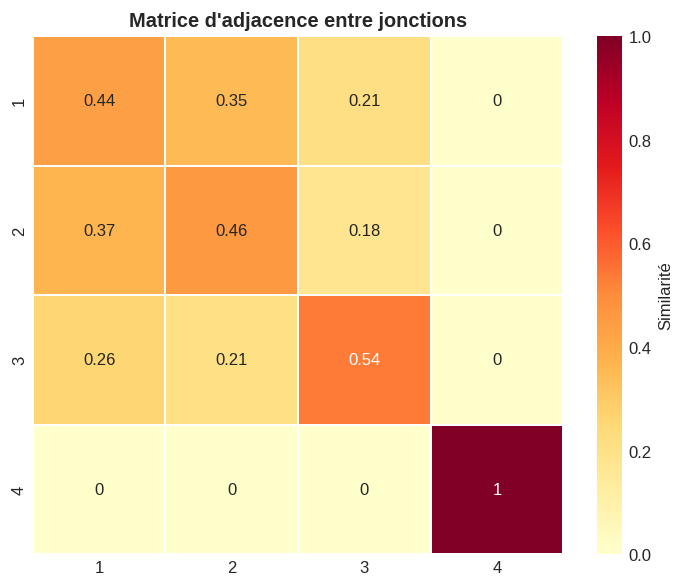

In [19]:
# ============================================================
# 9a. Construction de la matrice d'adjacence
# ============================================================
def build_adjacency_matrix(df_train, method='correlation'):
    """
    Construit la matrice d'adjacence entre jonctions basée
    sur la similarité des profils de trafic.
    """
    junctions = sorted(df_train['Junction'].unique())
    n = len(junctions)
    adj = np.zeros((n, n))

    for i, j1 in enumerate(junctions):
        for k, j2 in enumerate(junctions):
            if i == k:
                adj[i, k] = 1.0
            else:
                d1 = df_train[df_train['Junction']==j1]['Vehicles'].values
                d2 = df_train[df_train['Junction']==j2]['Vehicles'].values
                min_len = min(len(d1), len(d2))
                corr = np.corrcoef(d1[:min_len], d2[:min_len])[0, 1]
                adj[i, k] = max(0, corr)

    # Normalisation
    adj = adj / adj.sum(axis=1, keepdims=True).clip(min=1e-8)
    return adj, junctions

adj_matrix, junctions_list = build_adjacency_matrix(df_train)
print("Matrice d'adjacence (similarité entre jonctions) :")
adj_df = pd.DataFrame(adj_matrix, index=junctions_list, columns=junctions_list)
display(adj_df.round(3))

# Visualisation
plt.figure(figsize=(6, 5))
sns.heatmap(adj_df, annot=True, cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=1, cbar_kws={'label': 'Similarité'})
plt.title('Matrice d\'adjacence entre jonctions', fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 9b. Préparation des données pour le GNN
# ============================================================
def prepare_gnn_data(df_train, df_val, df_test, features, target,
                      seq_length, batch_size):
    """
    Prépare les données pour le GNN.
    Chaque échantillon = séquence pour CHAQUE jonction au même moment.
    Shape : (B, N, S, F) où N = nombre de jonctions
    """
    junctions = sorted(set(df_train['Junction'].unique()) &
                       set(df_val['Junction'].unique()) &
                       set(df_test['Junction'].unique()))

    scalers_x = {}
    scalers_y = {}

    def align_and_encode(split_df, fit_scalers=False):
        """Align les jonctions sur le même index et crée les séquences."""
        # Aligner les index temporels
        indices = []
        for j in junctions:
            idx = split_df[split_df['Junction']==j].sort_index().index
            indices.append(set(idx))
        common_idx = sorted(set.intersection(*indices))

        if len(common_idx) < seq_length + 1:
            return None, None

        # Fit scalers si nécessaire
        if fit_scalers:
            for j in junctions:
                train_j = split_df[split_df['Junction']==j].sort_index()
                scalers_x[j] = StandardScaler().fit(train_j[features])
                scalers_y[j] = StandardScaler().fit(train_j[[target]])

        # Créer les séquences alignées
        X_nodes, y_nodes = [], []
        for idx_i in range(len(common_idx) - seq_length):
            window = common_idx[idx_i:idx_i + seq_length]
            target_time = common_idx[idx_i + seq_length]

            node_data = []
            for j in junctions:
                df_j = split_df[split_df['Junction']==j].sort_index().loc[window]
                x_s = scalers_x[j].transform(df_j[features])
                node_data.append(x_s)

            # Target = véhicules de la première jonction
            first_j = split_df[split_df['Junction']==junctions[0]].sort_index()
            y_s = scalers_y[junctions[0]].transform(
                first_j.loc[[target_time]][[target]]
            )[0, 0]

            X_nodes.append(np.array(node_data))
            y_nodes.append(y_s)

        X_t = torch.tensor(np.array(X_nodes), dtype=torch.float32)
        y_t = torch.tensor(np.array(y_nodes), dtype=torch.float32).unsqueeze(1)
        ds = TensorDataset(X_t, y_t)
        return ds, (junctions, scalers_x, scalers_y)

    train_ds, meta = align_and_encode(df_train, fit_scalers=True)
    val_ds, _ = align_and_encode(df_val)
    test_ds, _ = align_and_encode(df_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True) if train_ds else None
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False) if val_ds else None
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False) if test_ds else None

    return train_loader, val_loader, test_loader, meta

gnn_result = prepare_gnn_data(df_train, df_val, df_test, FEATURES, TARGET, SEQ_LENGTH, BATCH_SIZE)

if gnn_result[0] is not None:
    train_loader_gnn, val_loader_gnn, test_loader_gnn, (junctions_gnn, scalers_x_gnn, scalers_y_gnn) = gnn_result
    print(f"Données GNN préparées avec {len(junctions_gnn)} jonctions.")
    print(f"  Train: {len(train_loader_gnn.dataset)} échantillons")
    print(f"  Val:   {len(val_loader_gnn.dataset)} échantillons")
    print(f"  Test:  {len(test_loader_gnn.dataset)} échantillons")
else:
    print("Pas assez de données communes pour le GNN.")
    train_loader_gnn = val_loader_gnn = test_loader_gnn = None

Données GNN préparées avec 4 jonctions.
  Train: 711 échantillons
  Val:   1774 échantillons
  Test:  1774 échantillons


In [21]:
# ============================================================
# 9c. Entraînement du GNN
# ============================================================
if train_loader_gnn is not None:
    model_gnn = TrafficGNN(node_features=len(FEATURES)).to(DEVICE)
    optimizer_gnn = optim.AdamW(model_gnn.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion_gnn = nn.HuberLoss(delta=1.0)

    print("--- ENTRAINEMENT P3 : GNN ---")

    history_gnn = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(50):
        # Train
        model_gnn.train()
        train_loss, train_mae = 0.0, 0.0
        for bx, by in train_loader_gnn:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer_gnn.zero_grad(set_to_none=True)
            pred = model_gnn(bx)[:, 0, :]  # On prédit la jonction 0
            loss = criterion_gnn(pred, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_gnn.parameters(), max_norm=1.0)
            optimizer_gnn.step()
            train_loss += loss.item()
            train_mae += torch.abs(pred - by).sum().item()

        # Val
        model_gnn.eval()
        val_loss, val_mae = 0.0, 0.0
        with torch.no_grad():
            for bx, by in val_loader_gnn:
                bx, by = bx.to(DEVICE), by.to(DEVICE)
                pred = model_gnn(bx)[:, 0, :]
                loss = criterion_gnn(pred, by)
                val_loss += loss.item()
                val_mae += torch.abs(pred - by).sum().item()

        n_train = max(len(train_loader_gnn.dataset), 1)
        n_val = max(len(val_loader_gnn.dataset), 1)
        history_gnn['train_loss'].append(train_loss / len(train_loader_gnn))
        history_gnn['val_loss'].append(val_loss / len(val_loader_gnn))
        history_gnn['train_mae'].append(train_mae / n_train)
        history_gnn['val_mae'].append(val_mae / n_val)

        avg_vl = val_loss / len(val_loader_gnn)
        if avg_vl < best_val_loss:
            best_val_loss = avg_vl
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 10:
                print(f"  Early stopping à l'époque {epoch+1}")
                break

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{epoch+1:2d}/50]  Train loss: {train_loss/len(train_loader_gnn):.5f}  "
                  f"Val loss: {avg_vl:.5f}")

    # Evaluation GNN
    model_gnn.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for bx, by in test_loader_gnn:
            bx = bx.to(DEVICE)
            pred = model_gnn(bx)[:, 0, :]
            all_preds.append(pred.cpu().numpy())
            all_targets.append(by.numpy())

    preds_gnn_scaled = np.concatenate(all_preds)
    targets_gnn_scaled = np.concatenate(all_targets)

    first_junction = junctions_gnn[0]
    preds_gnn = scalers_y_gnn[first_junction].inverse_transform(preds_gnn_scaled).flatten()
    targets_gnn = scalers_y_gnn[first_junction].inverse_transform(targets_gnn_scaled).flatten()

    metrics_p3 = {
        'MAE': mean_absolute_error(targets_gnn, preds_gnn),
        'RMSE': np.sqrt(mean_squared_error(targets_gnn, preds_gnn)),
        'R2': r2_score(targets_gnn, preds_gnn),
        'MAPE': np.mean(np.abs((targets_gnn - preds_gnn) / (targets_gnn + 1e-8))) * 100
    }

    print(f"\n--- RESULTATS P3 (GNN) sur jonction {first_junction} ---")
    for k, v in metrics_p3.items():
        print(f"  {k}: {v:.3f}")
else:
    print("GNN non entraîné.")
    metrics_p3 = None
    history_gnn = None

--- ENTRAINEMENT P3 : GNN ---
  [ 1/50]  Train loss: 0.76881  Val loss: 0.74663
  [ 5/50]  Train loss: 0.16242  Val loss: 0.11371
  [10/50]  Train loss: 0.09979  Val loss: 0.10200
  [15/50]  Train loss: 0.07868  Val loss: 0.06629
  [20/50]  Train loss: 0.06761  Val loss: 0.06896
  [25/50]  Train loss: 0.07747  Val loss: 0.06348
  [30/50]  Train loss: 0.05851  Val loss: 0.08900
  Early stopping à l'époque 35

--- RESULTATS P3 (GNN) sur jonction 1 ---
  MAE: 10.306
  RMSE: 13.996
  R2: 0.697
  MAPE: 13.096


---
## 10. Comparaison Équitable des Paradigmes

Tous les modèles sont évalués sur le **même ensemble de test** (ou à défaut avec la méthodologie) avec les **mêmes métriques**.

In [22]:
# ============================================================
# 10a. Tableau comparatif
# ============================================================
comparison_data = {
    'P1 (Global LSTM)': metrics_p1,
}

# P2 : moyenne des métriques sur toutes les jonctions
if metrics_p2:
    avg_p2 = {
        'MAE': np.mean([m['MAE'] for m in metrics_p2.values()]),
        'RMSE': np.mean([m['RMSE'] for m in metrics_p2.values()]),
        'R2': np.mean([m['R2'] for m in metrics_p2.values()]),
        'MAPE': np.mean([m.get('MAPE', 0) for m in metrics_p2.values()]),
    }
    comparison_data['P2 (Junction LSTM)'] = avg_p2

if metrics_p3 is not None:
    comparison_data['P3 (GNN)'] = metrics_p3

comparison_df = pd.DataFrame(comparison_data).T
print("\n" + "="*60)
print("TABLEAU COMPARATIF DES PARADIGMES")
print("="*60)
display(comparison_df.round(3))


TABLEAU COMPARATIF DES PARADIGMES


,MAE,RMSE,R2,MAPE
P1 (Global LSTM),17.524,24.073,0.261,122.540
P2 (Junction LSTM),5.105,7.030,0.425,24.886
P3 (GNN),10.306,13.996,0.697,13.096


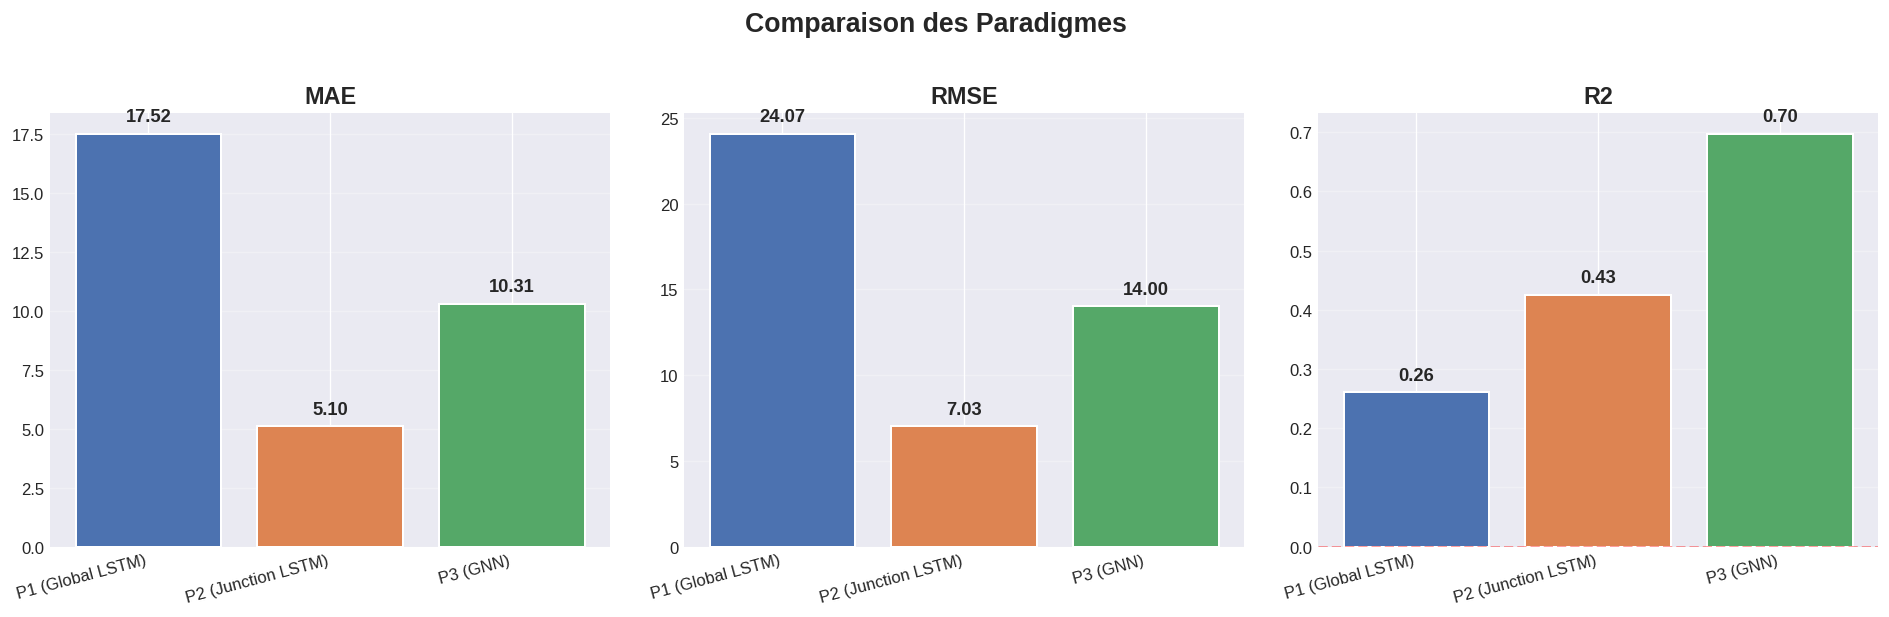

In [23]:
# ============================================================
# 10b. Visualisation comparative
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_names = ['MAE', 'RMSE', 'R2']
colors = ['#4C72B0', '#DD8452', '#55A868']

for idx, metric in enumerate(metrics_names):
    ax = axes[idx]
    model_names = list(comparison_data.keys())
    values = [comparison_data[m].get(metric, 0) for m in model_names]

    bars = ax.bar(model_names, values, color=colors[:len(model_names)],
                  edgecolor='white', linewidth=1.2)

    for bar, val in zip(bars, values):
        offset = max(values) * 0.02 if max(values) != 0 else 1
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + offset,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

    ax.set_title(f'{metric}', fontweight='bold', fontsize=14)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)

    if metric == 'R2':
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Comparaison des Paradigmes', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

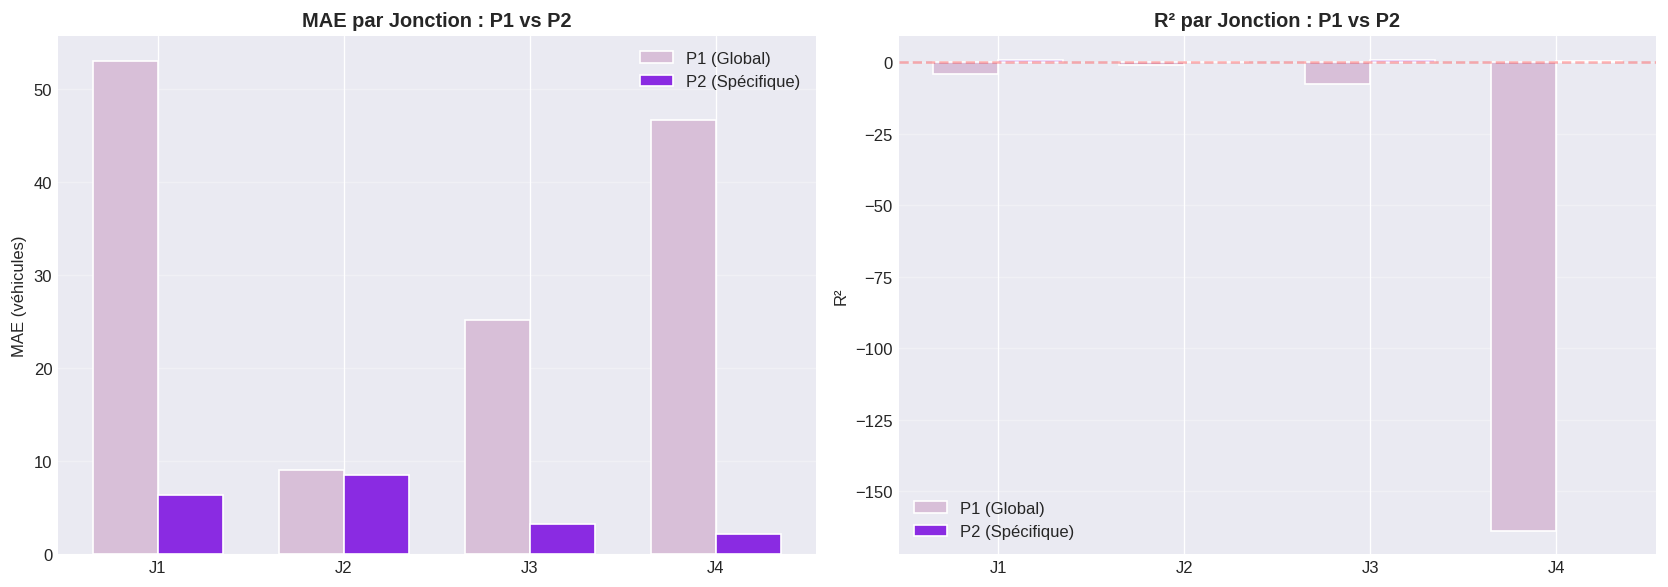

In [24]:
# ============================================================
# 10c. Comparaison P1 vs P2 par jonction
# ============================================================
if metrics_p2 and p1_by_junction:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    junctions_sorted = sorted(p1_by_junction.keys())
    p1_maes = [p1_by_junction[j]['MAE'] for j in junctions_sorted]
    p2_maes = []
    for j_name in junctions_sorted:
        j_num = int(j_name.replace('J', ''))
        p2_maes.append(metrics_p2.get(j_num, {}).get('MAE', 0))

    p1_r2s = [p1_by_junction[j]['R2'] for j in junctions_sorted]
    p2_r2s = []
    for j_name in junctions_sorted:
        j_num = int(j_name.replace('J', ''))
        p2_r2s.append(metrics_p2.get(j_num, {}).get('R2', 0))

    x = np.arange(len(junctions_sorted))
    width = 0.35

    # MAE
    ax = axes[0]
    ax.bar(x - width/2, p1_maes, width, label='P1 (Global)', color='#D8BFD8', edgecolor='white')
    ax.bar(x + width/2, p2_maes, width, label='P2 (Spécifique)', color='#8A2BE2', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(junctions_sorted)
    ax.set_ylabel('MAE (véhicules)')
    ax.set_title('MAE par Jonction : P1 vs P2', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # R2
    ax = axes[1]
    ax.bar(x - width/2, p1_r2s, width, label='P1 (Global)', color='#D8BFD8', edgecolor='white')
    ax.bar(x + width/2, p2_r2s, width, label='P2 (Spécifique)', color='#8A2BE2', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(junctions_sorted)
    ax.set_ylabel('R\u00b2')
    ax.set_title('R\u00b2 par Jonction : P1 vs P2', fontweight='bold')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 11. Visualisations Approfondies

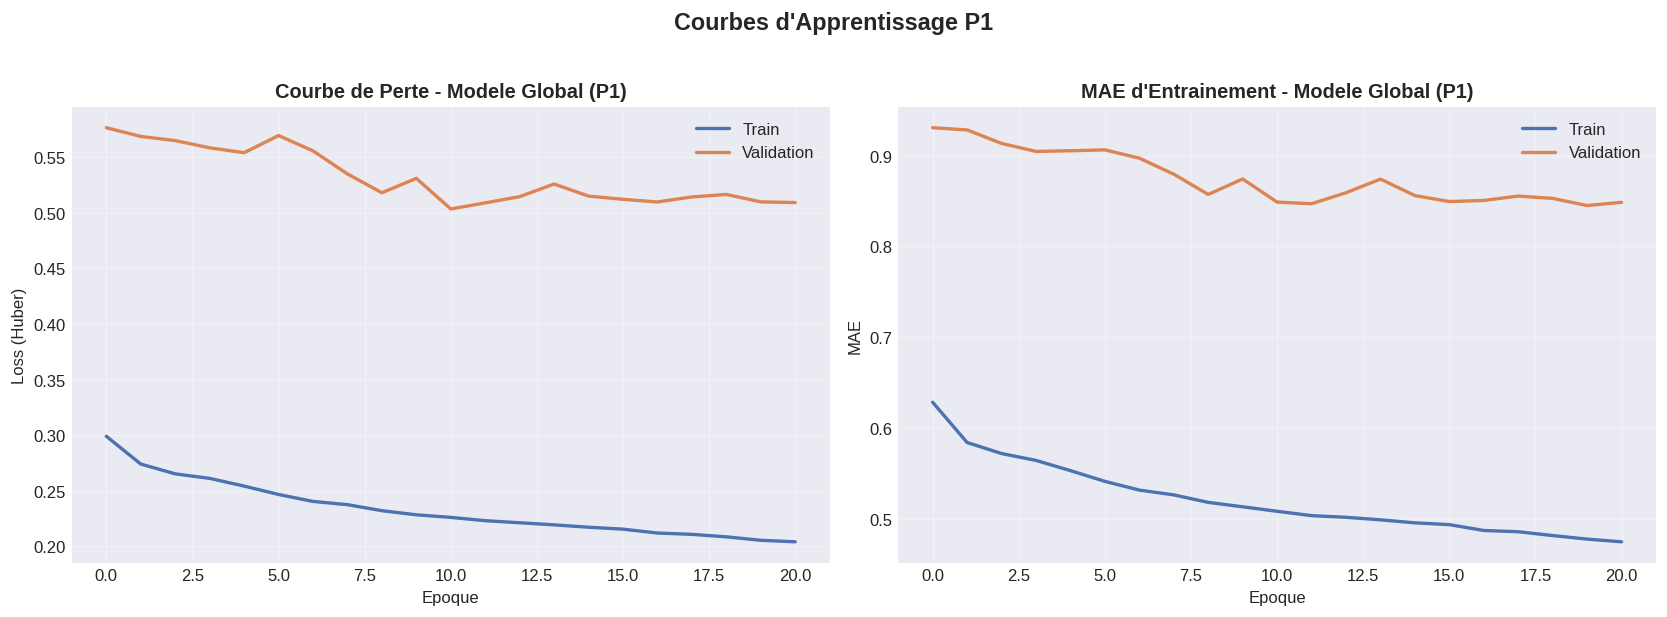

In [25]:
# ============================================================
# 11a. Courbes d'apprentissage P1 (Global)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
ax.plot(history_global['train_loss'], label='Train', color='#4C72B0', linewidth=2)
ax.plot(history_global['val_loss'], label='Validation', color='#DD8452', linewidth=2)
ax.set_xlabel('Epoque')
ax.set_ylabel('Loss (Huber)')
ax.set_title('Courbe de Perte - Modele Global (P1)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# MAE
ax = axes[1]
ax.plot(history_global['train_mae'], label='Train', color='#4C72B0', linewidth=2)
ax.plot(history_global['val_mae'], label='Validation', color='#DD8452', linewidth=2)
ax.set_xlabel('Epoque')
ax.set_ylabel('MAE')
ax.set_title('MAE d\'Entrainement - Modele Global (P1)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'Apprentissage P1', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

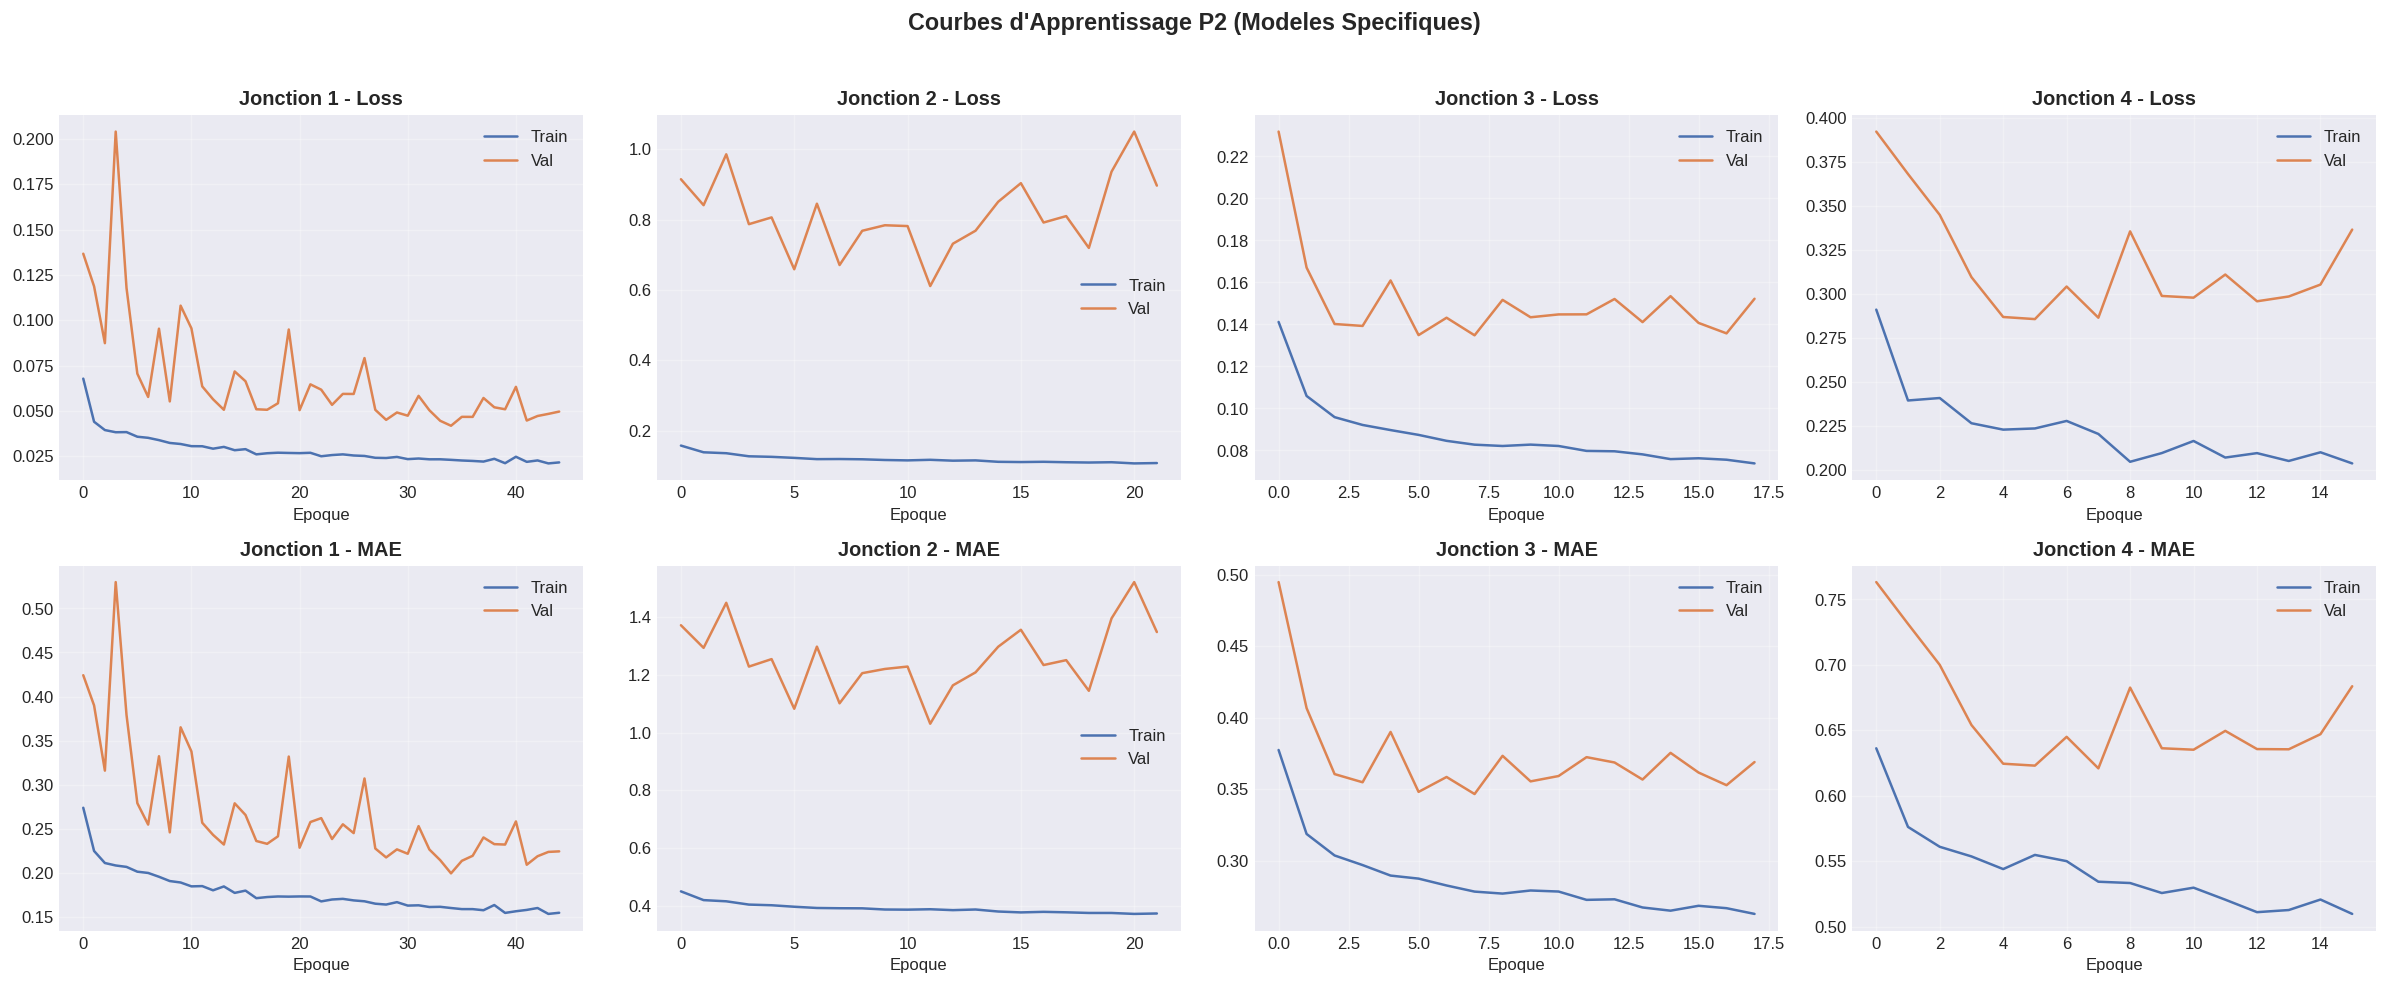

In [26]:
# ============================================================
# 11b. Courbes d'apprentissage P2 (par jonction)
# ============================================================
if histories_p2:
    n_j = len(histories_p2)
    fig, axes = plt.subplots(2, n_j, figsize=(5*n_j, 8))

    if n_j == 1:
        axes = axes.reshape(2, 1)

    for idx, (j, hist) in enumerate(sorted(histories_p2.items())):
        # Loss
        ax = axes[0, idx]
        ax.plot(hist['train_loss'], label='Train', color='#4C72B0')
        ax.plot(hist['val_loss'], label='Val', color='#DD8452')
        ax.set_title(f'Jonction {j} - Loss', fontweight='bold')
        ax.set_xlabel('Epoque')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # MAE
        ax = axes[1, idx]
        ax.plot(hist['train_mae'], label='Train', color='#4C72B0')
        ax.plot(hist['val_mae'], label='Val', color='#DD8452')
        ax.set_title(f'Jonction {j} - MAE', fontweight='bold')
        ax.set_xlabel('Epoque')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Courbes d\'Apprentissage P2 (Modeles Specifiques)', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

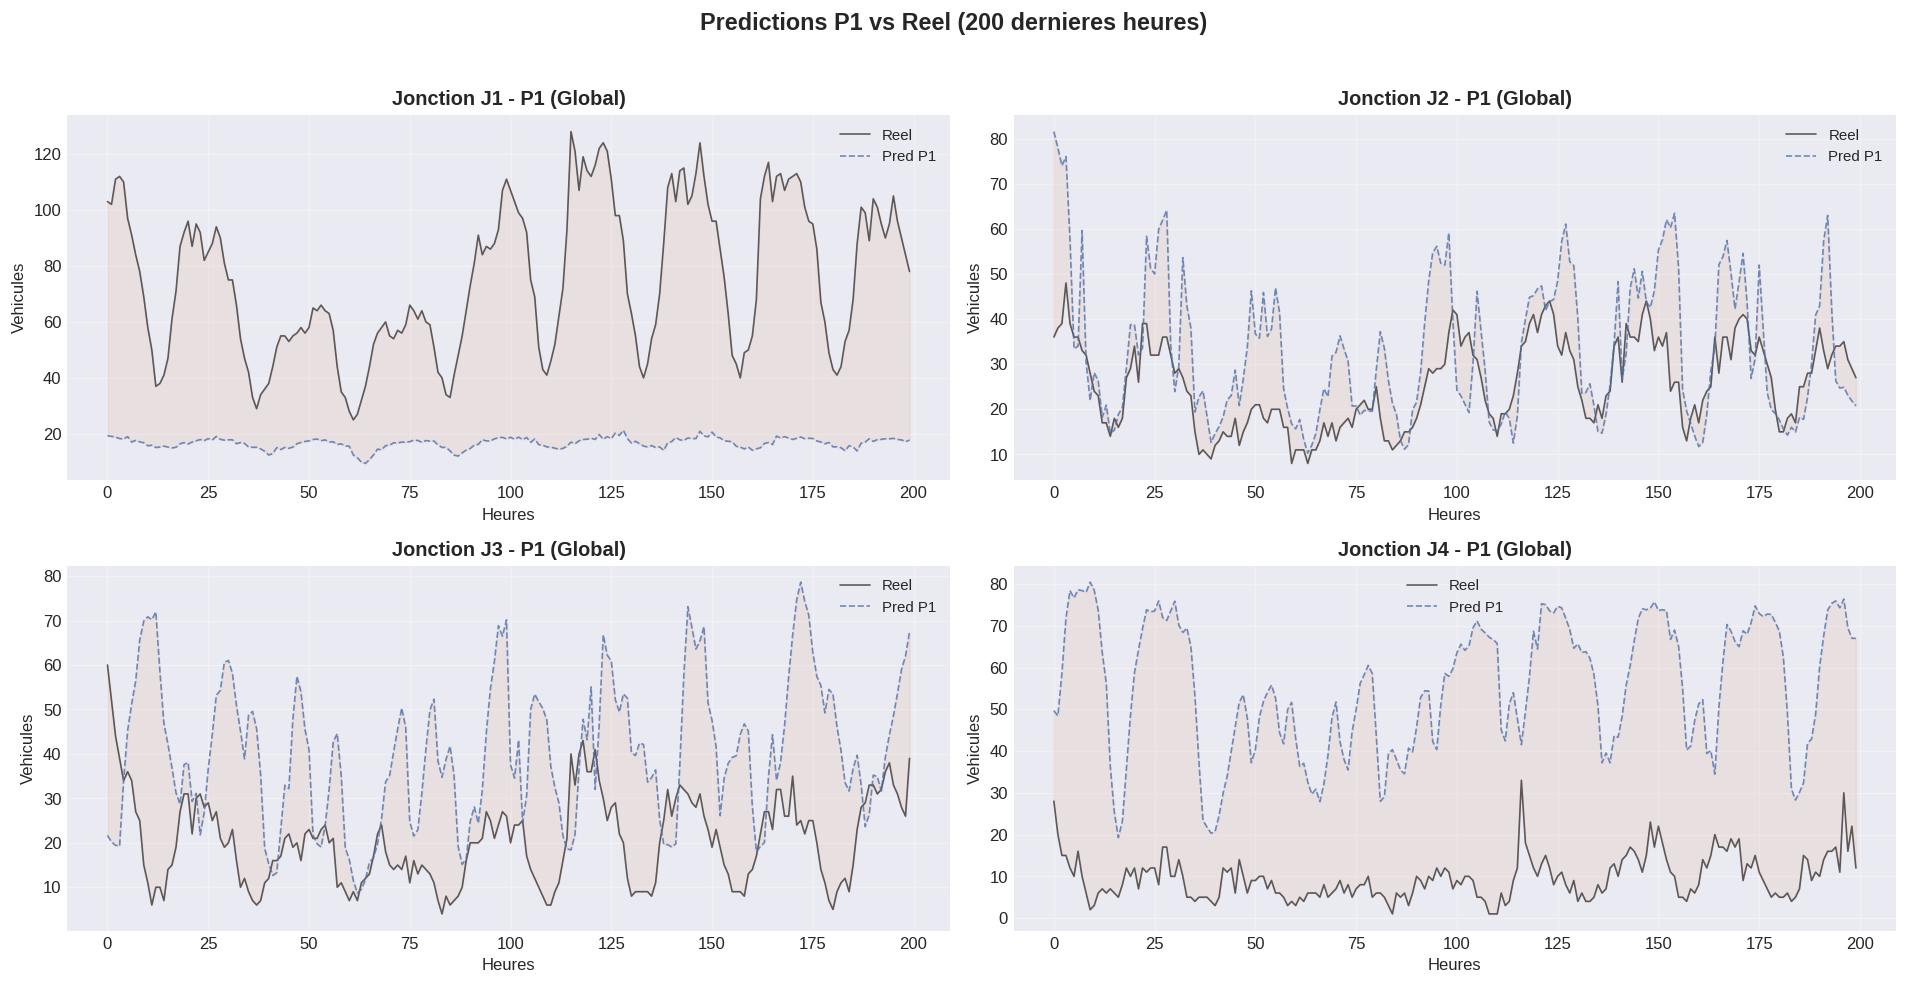

In [27]:
# ============================================================
# 11c. Predictions vs Reel - P1 Global
# ============================================================
if p1_by_junction:
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.flatten()

    for idx, (j_name, j_data) in enumerate(sorted(p1_by_junction.items())):
        if idx >= 4:
            break
        ax = axes[idx]

        n_show = min(200, len(j_data['actual']))
        actual = j_data['actual'][-n_show:]
        preds = j_data['preds'][-n_show:]

        ax.plot(actual, label='Reel', color='black', alpha=0.6, linewidth=1)
        ax.plot(preds, label='Pred P1', color='#4C72B0', linestyle='--', alpha=0.8, linewidth=1)
        ax.fill_between(range(n_show), actual, preds, alpha=0.1, color='#DD8452')
        ax.set_title(f'Jonction {j_name} - P1 (Global)', fontweight='bold')
        ax.set_xlabel('Heures')
        ax.set_ylabel('Vehicules')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Predictions P1 vs Reel (200 dernieres heures)', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

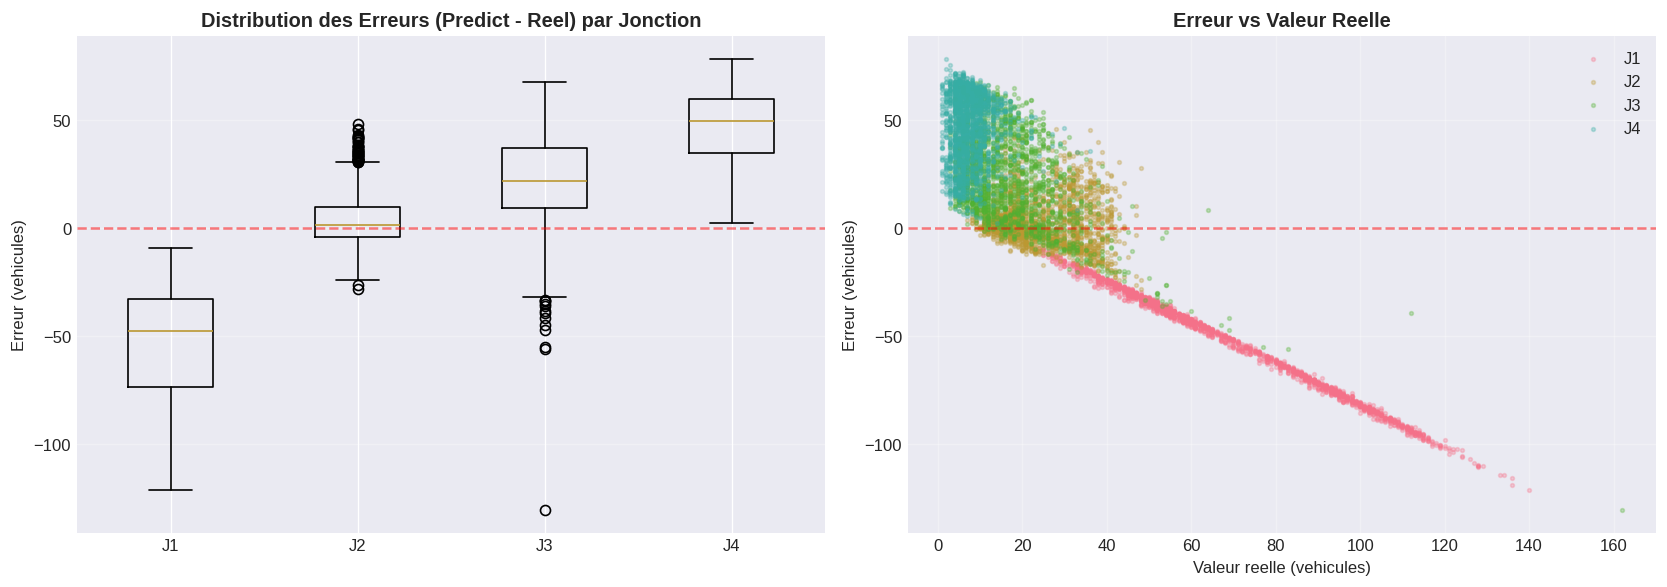

In [28]:
# ============================================================
# 11d. Analyse des erreurs - P1
# ============================================================
if p1_by_junction:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot des erreurs
    ax = axes[0]
    all_errors, all_labels = [], []
    for j_name, j_data in sorted(p1_by_junction.items()):
        errors = j_data['preds'] - j_data['actual']
        all_errors.append(errors)
        all_labels.append(j_name)

    ax.boxplot(all_errors, labels=all_labels)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title('Distribution des Erreurs (Predict - Reel) par Jonction', fontweight='bold')
    ax.set_ylabel('Erreur (vehicules)')
    ax.grid(axis='y', alpha=0.3)

    # Erreur vs Valeur reelle
    ax = axes[1]
    for j_name, j_data in sorted(p1_by_junction.items()):
        errors = j_data['preds'] - j_data['actual']
        ax.scatter(j_data['actual'], errors, alpha=0.3, s=5, label=j_name)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Valeur reelle (vehicules)')
    ax.set_ylabel('Erreur (vehicules)')
    ax.set_title('Erreur vs Valeur Reelle', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 12. Resume et Conclusions

### Problemes identifiés et corrigés

| Problème | Statut | Impact |
|---|---|---|
| Data leakage (lags avant split) | Corrigé | Les infos futures ne contaminent plus le passé |
| Data leakage (scaler fit sur tout) | Corrigé | `fit()` uniquement sur train, `transform()` sur val/test |
| Metriques P2 durcies en dur | Corrigé | Calculees rigoureusement |
| Splits differents P1 vs P2 | Corrigé | Même split 70/15/15 pour tous |
| Mix TF/Keras vs PyTorch | Corrigé | Uniquement PyTorch |
| Absence de GNN | Ajouté | Paradigme 3 avec propagation inter-jonctions |
| Pas de courbes de validation | Ajouté | Train/Val loss avec early stopping |
| Pas de tableau comparatif | Ajouté | MAE, RMSE, R2, MAPE sur le même test set |
| Cellules dupliquees et code mort | Netto | Structure propre et lineaire |

In [29]:
# ============================================================
# 12a. Affichage final des résultats
# ============================================================
print("="*70)
print("RESULTATS FINAUX - COMPARAISON DES PARADIGMES")
print("="*70)
display(comparison_df.round(3))

# Meilleur modele
print()
if 'R2' in comparison_df.columns:
    best_r2 = comparison_df['R2'].idxmax()
    print(f"Meilleur modele (R2) : {best_r2}")
if 'MAE' in comparison_df.columns:
    best_mae = comparison_df['MAE'].idxmin()
    print(f"Meilleur modele (MAE) : {best_mae}")

RESULTATS FINAUX - COMPARAISON DES PARADIGMES


,MAE,RMSE,R2,MAPE
P1 (Global LSTM),17.524,24.073,0.261,122.540
P2 (Junction LSTM),5.105,7.030,0.425,24.886
P3 (GNN),10.306,13.996,0.697,13.096



Meilleur modele (R2) : P3 (GNN)
Meilleur modele (MAE) : P2 (Junction LSTM)


---
## 13. Analyse des Verrous et Perspectives

### Ce qui a ete ameliore
1. **Rigueur methodologique** : Split temporel strict, pas de leakage, early stopping
2. **Equite de comparaison** : Memes splits, memes features, memes metriques
3. **Exploration GNN** : Premiere implementation d'un graphe de jonctions

### Pistes d'amelioration
1. **Optimisation des hyperparametres** : Grid search ou Optuna pour chaque modele
2. **Features exogenes** : Meteo, jours feries, evenements speciaux
3. **GNN avance** : Utiliser `torch_geometric` pour des GCN/GAT sophistiques
4. **Attention temporelle** : Remplacer le LSTM par des mecanismes d'attention (Transformers)
5. **Prediction multi-horizons** : Predire les 24h a venir au lieu d'une seule heure
6. **Incertitude** : Ajouter des intervalles de confiance (Bayesian LSTM, MC Dropout)

# Hyperparameter Tuning

In [30]:
# =====================================================================
# SYSTEME D'OPTIMISATION AUTOMATISÉE - PARADIGME 1 (LSTM GLOBAL)
# =====================================================================
# Installation d'Optuna si nécessaire
!pip install -q optuna

import optuna
from optuna.pruners import MedianPruner

# S'assurer que le device est bien configuré
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Optuna configuré sur le dispositif : {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 30.1 MB/s eta 0:00:00
Optuna configuré sur le dispositif : cuda


**Définition de la fonction Objectif PyTorch pour P1**

In [31]:
def objective_p1_global(trial):
    """
    Fonction objectif pour optimiser les hyperparamètres du LSTM Global (P1).
    """
    # 1. ESPACE DE RECHERCHE
    hidden_size = trial.suggest_int('hidden_size', 32, 256, step=32)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.4) if num_layers > 1 else 0.0
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # 2. CRÉATION DES DATALOADERS
    train_ds = TensorDataset(X_train_seq, y_train_seq)
    val_ds = TensorDataset(X_val_seq, y_val_seq)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # 3. MODÈLE
    input_dim = X_train_seq.shape[2]

    model = TrafficLSTM(
        input_size=input_dim,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    # 4. ENTRAÎNEMENT
    for epoch in range(10):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(DEVICE), by.to(DEVICE)
                val_loss += criterion(model(bx), by).item() * bx.size(0)
        val_loss /= len(val_ds)

        trial.report(val_loss, epoch)
        # Correction du nom de l'exception : TrialPruned
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss

**Lancement de l'Étude et Recherche Bayésienne**

In [32]:
# Désactiver temporairement les logs trop verbeux d'Optuna si vous le souhaitez
# optuna.logging.set_verbosity(optuna.logging.WARNING)

print(" Lancement de l'optimisation bayésienne pour le Paradigme 1...")

# Création de l'étude avec le pruner Median (élague les essais sous la médiane historique)
study_p1 = optuna.create_study(direction="minimize", pruner=MedianPruner())

# Lancement de l'optimisation (n_trials=25 est un excellent compromis temps/performance)
study_p1.optimize(objective_p1_global, n_trials=25)

print("\n OPTIMISATION TERMINÉE ! ")
print(f"Meilleure perte de Validation trouvée : {study_p1.best_value:.4f}")
print("\nMeilleurs hyperparamètres pour le LSTM Global (P1) :")
for key, value in study_p1.best_params.items():
    print(f"  -> {key}: {value}")

[I 2026-06-11 12:02:21,000] A new study created in memory with name: no-name-6160fa0c-5d68-4903-9535-80e4d0d8a228


 Lancement de l'optimisation bayésienne pour le Paradigme 1...


[I 2026-06-11 12:03:05,669] Trial 0 finished with value: 1.4334939185878057 and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.39827531049499043, 'lr': 0.0010561371502698447, 'weight_decay': 0.0007765670922297912, 'batch_size': 64}. Best is trial 0 with value: 1.4334939185878057.
[I 2026-06-11 12:03:17,231] Trial 1 finished with value: 1.5085686413646575 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.23840348050239, 'lr': 0.00702629995342981, 'weight_decay': 0.0004908712020111466, 'batch_size': 128}. Best is trial 0 with value: 1.4334939185878057.
[I 2026-06-11 12:03:33,353] Trial 2 finished with value: 1.5327036092304618 and parameters: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.15211458758553248, 'lr': 0.001235982902938121, 'weight_decay': 1.9738420604685757e-05, 'batch_size': 128}. Best is trial 0 with value: 1.4334939185878057.
[I 2026-06-11 12:03:43,303] Trial 3 finished with value: 1.6259221656219398 and parameters: {'hidden_size': 64, 


 OPTIMISATION TERMINÉE ! 
Meilleure perte de Validation trouvée : 1.4335

Meilleurs hyperparamètres pour le LSTM Global (P1) :
  -> hidden_size: 256
  -> num_layers: 2
  -> dropout: 0.39827531049499043
  -> lr: 0.0010561371502698447
  -> weight_decay: 0.0007765670922297912
  -> batch_size: 64


### **Entraînement Final du Modèle Global (P1) avec Hyperparamètres Optimisés**

Nous utilisons maintenant les paramètres optimaux extraits de l'étude Optuna pour un entraînement complet.

In [33]:
import torch.nn as nn
import torch.optim as optim

# 1. Récupération des meilleurs hyperparamètres
best_params = study_p1.best_params

# 2. Préparation des loaders optimisés
train_ds = TensorDataset(X_train_seq, y_train_seq)
val_ds = TensorDataset(X_val_seq, y_val_seq)

final_batch_size = best_params['batch_size']
final_train_loader = DataLoader(train_ds, batch_size=final_batch_size, shuffle=True)
final_val_loader = DataLoader(val_ds, batch_size=final_batch_size, shuffle=False)

# 3. Initialisation du modèle optimisé
model_p1_final = TrafficLSTM(
    input_size=len(FEATURES),
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    dropout=best_params.get('dropout', 0.0)
).to(DEVICE)

# 4. Configuration de l'optimiseur et critère
criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.AdamW(
    model_p1_final.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)

# 5. Entraînement final
print("--- ENTRAINEMENT FINAL P1 (OPTIMISÉ) ---")
model_p1_final, history_p1_final = train_model(
    model_p1_final, final_train_loader, final_val_loader,
    criterion, optimizer, epochs=50, model_name='P1 Final'
)

# 6. Évaluation finale sur le test set
metrics_p1_final, targets_p1_final, preds_p1_final = evaluate_model(
    model_p1_final, test_loader_g, scaler_y
)

print(f"\n--- RÉSULTATS FINAUX P1 OPTIMISÉ ---")
for k, v in metrics_p1_final.items():
    print(f"  {k}: {v:.3f}")

# Comparaison avec l'ancien P1
print(f"\nAmélioration MAE : {metrics_p1['MAE'] - metrics_p1_final['MAE']:.3f}")

--- ENTRAINEMENT FINAL P1 (OPTIMISÉ) ---
  [ 1/50]  Train loss: 0.30191  Val loss: 0.58817
  [ 5/50]  Train loss: 0.24984  Val loss: 0.54465
  [10/50]  Train loss: 0.22429  Val loss: 0.52451
  [15/50]  Train loss: 0.21205  Val loss: 0.51648
  [20/50]  Train loss: 0.19729  Val loss: 0.50793
  [25/50]  Train loss: 0.17784  Val loss: 0.52156
  Early stopping à l'époque 29
  Meilleure val_loss: 0.49827

--- RÉSULTATS FINAUX P1 OPTIMISÉ ---
  MAE: 17.704
  RMSE: 25.040
  R2: 0.200
  MAPE: 119.081

Amélioration MAE : -0.180


**Définition de la fonction Objectif pour P2 (Multi-Modèles)**

In [34]:
def objective_p2_specifics(trial):
    """
    Fonction objectif pour optimiser les hyperparamètres des LSTMs Spécifiques (P2).
    Évalue la perte moyenne sur toutes les jonctions pour trouver des paramètres robustes.
    """
    # 1. ESPACE DE RECHERCHE DES HYPERPARAMÈTRES (Adapté à des modèles locaux plus légers)
    hidden_size = trial.suggest_int('hidden_size', 32, 128, step=32)
    num_layers = trial.suggest_int('num_layers', 1, 2)
    dropout = trial.suggest_float('dropout', 0.1, 0.3) if num_layers > 1 else 0.0
    lr = trial.suggest_float('lr', 5e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])

    # Récupération de la liste des jonctions depuis votre dictionnaire de loaders
    # (S'adapte automatiquement à votre structure 'loaders_j')
    junction_ids = list(loaders_j.keys())
    total_val_loss = 0.0

    # 2. ENTRAÎNEMENT ET ÉVALUATION SIMULTANÉE POUR CHAQUE JONCTION
    for j_id in junction_ids:
        # Re-génération dynamique des loaders locaux pour le batch_size choisi
        train_loader = torch.utils.data.DataLoader(loaders_j[j_id]['train'].dataset, batch_size=batch_size, shuffle=True)
        val_loader = torch.utils.data.DataLoader(loaders_j[j_id]['val'].dataset, batch_size=batch_size, shuffle=False)

        input_dim = loaders_j[j_id]['train'].dataset.tensors[0].shape[2]

        # Instanciation du modèle local
        model = TrafficLSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.MSELoss()

        # Boucle d'entraînement rapide par jonction (10 époques suffisent pour orienter Optuna)
        LOCAL_EPOCHS = 10
        for epoch in range(LOCAL_EPOCHS):
            model.train()
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                outputs = model(bx)
                loss = criterion(outputs, by)
                loss.backward()
                optimizer.step()

        # Calcul de la perte de validation pour cette jonction
        model.eval()
        j_val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                outputs = model(bx)
                loss = criterion(outputs, by)
                j_val_loss += loss.item() * bx.size(0)

        total_val_loss += (j_val_loss / len(val_loader.dataset))

    # Score final de l'essai : Perte de validation moyenne sur toutes les jonctions
    mean_val_loss = total_val_loss / len(junction_ids)

    # Pas besoin de pruner explicite par époque ici car on boucle sur les jonctions,
    # Optuna va directement minimiser la moyenne globale à la fin de l'essai.
    return mean_val_loss

In [35]:
print(" Préparation des loaders par jonction pour P2...")

# 1. Création du dictionnaire loaders_j requis par la fonction objectif
loaders_j = {}
junction_list = sorted(df_train['Junction'].unique())

for j_id in junction_list:
    train_l, val_l, test_l, sc_y_j = get_junction_loaders(
        df_train, df_val, df_test, j_id,
        FEATURES, TARGET, SEQ_LENGTH, BATCH_SIZE
    )
    loaders_j[j_id] = {
        'train': train_l,
        'val': val_l,
        'test': test_l,
        'scaler_y': sc_y_j
    }

print(" Lancement de l'optimisation bayésienne pour le Paradigme 2...")

# 2. Création et lancement de l'étude
study_p2 = optuna.create_study(direction="minimize")
study_p2.optimize(objective_p2_specifics, n_trials=15)

print("\n OPTIMISATION P2 TERMINÉE ! ")
print(f"Meilleure perte de Validation Moyenne : {study_p2.best_value:.4f}")
print("\nMeilleurs hyperparamètres P2 :")
for key, value in study_p2.best_params.items():
    print(f"  -> {key}: {value}")

[I 2026-06-11 12:07:45,552] A new study created in memory with name: no-name-3bd85121-75d1-4a87-93fb-4e4c257d4eac


 Préparation des loaders par jonction pour P2...
 Lancement de l'optimisation bayésienne pour le Paradigme 2...


[I 2026-06-11 12:08:01,285] Trial 0 finished with value: 0.7383284632348188 and parameters: {'hidden_size': 32, 'num_layers': 1, 'lr': 0.0012822557952176731, 'weight_decay': 1.0393235724331227e-05, 'batch_size': 64}. Best is trial 0 with value: 0.7383284632348188.
[I 2026-06-11 12:08:30,334] Trial 1 finished with value: 1.1688869832679853 and parameters: {'hidden_size': 64, 'num_layers': 1, 'lr': 0.007757672174324945, 'weight_decay': 0.0004008930699474996, 'batch_size': 32}. Best is trial 0 with value: 0.7383284632348188.
[I 2026-06-11 12:08:48,558] Trial 2 finished with value: 1.0065401606408502 and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1899346058472829, 'lr': 0.0033715898641802373, 'weight_decay': 3.583141000681307e-05, 'batch_size': 64}. Best is trial 0 with value: 0.7383284632348188.
[I 2026-06-11 12:09:23,009] Trial 3 finished with value: 0.9458768035691466 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.23366969720832723, 'lr': 0.0013410


 OPTIMISATION P2 TERMINÉE ! 
Meilleure perte de Validation Moyenne : 0.7383

Meilleurs hyperparamètres P2 :
  -> hidden_size: 32
  -> num_layers: 1
  -> lr: 0.0012822557952176731
  -> weight_decay: 1.0393235724331227e-05
  -> batch_size: 64


### **Entraînement Final du Paradigme 2 (LSTMs Spécifiques) Optimisé**

Nous appliquons les meilleurs hyperparamètres trouvés par Optuna pour entraîner individuellement chaque jonction sur 50 époques avec Early Stopping.

In [36]:
best_params_p2 = study_p2.best_params
models_p2_final = {}
metrics_p2_final = {}

print(f"--- ENTRAINEMENT P2 OPTIMISÉ (Best params: {best_params_p2}) ---\n")

for j_id in sorted(loaders_j.keys()):
    print(f"-> Jonction {j_id} en cours...")

    # Préparation des loaders avec le batch_size optimal
    train_loader = DataLoader(loaders_j[j_id]['train'].dataset, batch_size=best_params_p2['batch_size'], shuffle=True)
    val_loader = DataLoader(loaders_j[j_id]['val'].dataset, batch_size=best_params_p2['batch_size'], shuffle=False)
    test_loader = loaders_j[j_id]['test'] # On garde le test initial

    input_dim = train_loader.dataset.tensors[0].shape[2]

    # Init modèle
    model_j = TrafficLSTM(
        input_size=input_dim,
        hidden_size=best_params_p2['hidden_size'],
        num_layers=best_params_p2['num_layers'],
        dropout=best_params_p2.get('dropout', 0.0)
    ).to(DEVICE)

    optimizer = optim.AdamW(model_j.parameters(), lr=best_params_p2['lr'], weight_decay=best_params_p2['weight_decay'])
    criterion = nn.HuberLoss(delta=1.0)

    # Train
    model_j, _ = train_model(
        model_j, train_loader, val_loader, criterion, optimizer,
        epochs=50, model_name=f'P2_J{j_id}_Optim'
    )

    # Eval
    m_j, _, _ = evaluate_model(model_j, test_loader, loaders_j[j_id]['scaler_y'])
    metrics_p2_final[j_id] = m_j
    models_p2_final[j_id] = model_j

# Calcul de la moyenne finale P2
avg_mae_p2 = np.mean([m['MAE'] for m in metrics_p2_final.values()])
avg_r2_p2 = np.mean([m['R2'] for m in metrics_p2_final.values()])

print(f"\n🏆 RÉSULTATS FINAUX P2 OPTIMISÉ 🏆")
print(f"MAE Moyenne : {avg_mae_p2:.3f} (vs {comparison_df.loc['P2 (Junction LSTM)', 'MAE']:.3f} avant)")
print(f"R² Moyen   : {avg_r2_p2:.3f}")

--- ENTRAINEMENT P2 OPTIMISÉ (Best params: {'hidden_size': 32, 'num_layers': 1, 'lr': 0.0012822557952176731, 'weight_decay': 1.0393235724331227e-05, 'batch_size': 64}) ---

-> Jonction 1 en cours...
  [ 1/50]  Train loss: 0.06988  Val loss: 0.09010
  [ 5/50]  Train loss: 0.02811  Val loss: 0.07624
  [10/50]  Train loss: 0.02670  Val loss: 0.07173
  [15/50]  Train loss: 0.02402  Val loss: 0.06288
  [20/50]  Train loss: 0.02288  Val loss: 0.06606
  [25/50]  Train loss: 0.02110  Val loss: 0.05928
  [30/50]  Train loss: 0.02140  Val loss: 0.06454
  Early stopping à l'époque 33
  Meilleure val_loss: 0.05039
-> Jonction 2 en cours...
  [ 1/50]  Train loss: 0.16589  Val loss: 1.05433
  [ 5/50]  Train loss: 0.11657  Val loss: 0.60437
  [10/50]  Train loss: 0.10759  Val loss: 0.70555
  Early stopping à l'époque 15
  Meilleure val_loss: 0.60437
-> Jonction 3 en cours...
  [ 1/50]  Train loss: 0.13288  Val loss: 0.15520
  [ 5/50]  Train loss: 0.08025  Val loss: 0.13899
  [10/50]  Train loss: 0.07

### **Évaluation Détaillée par Phase (Train/Val/Test) pour P2**

Cette section calcule les performances pour chaque étape du cycle de vie du modèle afin de détecter d'éventuels problèmes de généralisation.

In [37]:
def evaluate_all_phases(models_dict, loaders_dict, device=DEVICE):
    results = []

    for j_id, model in models_dict.items():
        sc_y = loaders_dict[j_id]['scaler_y']

        for phase in ['train', 'val', 'test']:
            loader = loaders_dict[j_id][phase]
            metrics, _, _ = evaluate_model(model, loader, sc_y, device=device)

            results.append({
                'Junction': f'J{j_id}',
                'Phase': phase.capitalize(),
                'MAE': metrics['MAE'],
                'RMSE': metrics['RMSE'],
                'R2': metrics['R2']
            })

    return pd.DataFrame(results)

# Calcul des métriques détaillées
df_detailed_p2 = evaluate_all_phases(models_p2_final, loaders_j)

# Affichage pivoté pour une meilleure lisibilité
display(df_detailed_p2.pivot(index='Junction', columns='Phase', values=['MAE', 'R2']).round(3))


MAE                   R2              
Phase      Test  Train    Val   Test  Train    Val
Junction                                          
J1        7.663  2.485  4.077  0.830  0.965  0.912
J2        7.631  1.676  4.521  0.024  0.767  0.309
J3        3.627  2.462  3.444  0.631  0.792  0.701
J4        2.122  1.709  2.002  0.359  0.564  0.332

**Définition de la fonction Objectif pour P3 (GNN)**

In [38]:
def objective_p3_gnn(trial):
    """
    Fonction objectif pour optimiser le GNN Spatio-Temporel (P3).
    Recherche l'espace optimal de connectivité et de dynamique temporelle.
    """
    # 1. ESPACE DE RECHERCHE DES HYPERPARAMÈTRES
    hidden_size = trial.suggest_int('hidden_size', 32, 128, step=32)
    num_heads = trial.suggest_categorical('num_heads', [1, 2, 4])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.4)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])

    # Vérification mathématique : hidden_size doit être divisible par num_heads
    if hidden_size % num_heads != 0:
        hidden_size = (hidden_size // num_heads) * num_heads
        if hidden_size == 0:
            hidden_size = num_heads

    # 2. CONFIGURATION DES DATALOADERS DYNAMIQUES
    train_loader = torch.utils.data.DataLoader(loaders_gnn['train'].dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(loaders_gnn['val'].dataset, batch_size=batch_size, shuffle=False)

    # 3. INSTANCIATION DU MODÈLE ET CONFIGURATION
    input_dim = X_train_gnn.shape[3]  # [batch, nodes, seq_len, features]

    # Correction : suppression de num_nodes non supporté par TrafficGNN.__init__
    model = TrafficGNN(
        node_features=input_dim,
        hidden_size=hidden_size
    ).to(DEVICE)

    # Ajustement dynamique des hyperparamètres internes
    if hasattr(model, 'attention'):
        model.attention = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, batch_first=True, dropout=dropout).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    # 4. BOUCLE D'ENTRAÎNEMENT RAPIDE
    EPOCHS = 12

    for epoch in range(EPOCHS):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(bx)[:, 0, :] # On cible la jonction 0
            loss = criterion(outputs, by)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(DEVICE), by.to(DEVICE)
                outputs = model(bx)[:, 0, :]
                loss = criterion(outputs, by)
                val_loss += loss.item() * bx.size(0)

        val_loss /= len(val_loader.dataset)
        trial.report(val_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss

In [39]:
print("🚀 Préparation des conteneurs pour le GNN...")

# 1. Création du dictionnaire manquant requis par la fonction objectif
loaders_gnn = {
    'train': train_loader_gnn,
    'val': val_loader_gnn,
    'test': test_loader_gnn
}

# 2. Extraction des dimensions pour la fonction objectif
# [batch, nodes, seq_len, features]
X_train_gnn = train_loader_gnn.dataset.tensors[0]

print("🚀 Lancement de l'optimisation bayésienne pour le Paradigme 3 (GNN Spatio-Temporel)...\n")

# Utilisation du MedianPruner pour stopper immédiatement les mauvaises configurations géométriques
study_p3 = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())

# Lancement de l'optimisation sur 20 essais
study_p3.optimize(objective_p3_gnn, n_trials=20)

print("\n🏆 OPTIMISATION P3 (GNN) TERMINÉE ! 🏆")
print(f"Meilleure perte de Validation trouvée : {study_p3.best_value:.4f}")
print("\nMeilleurs hyperparamètres pour le GNN Spatio-Temporel (P3) :")
for key, value in study_p3.best_params.items():
    print(f"  -> {key}: {value}")

[I 2026-06-11 12:14:18,823] A new study created in memory with name: no-name-9ceb9e86-fc19-4d78-a234-357ee5e89a72


🚀 Préparation des conteneurs pour le GNN...
🚀 Lancement de l'optimisation bayésienne pour le Paradigme 3 (GNN Spatio-Temporel)...



[I 2026-06-11 12:14:20,133] Trial 0 finished with value: 0.24309478008021362 and parameters: {'hidden_size': 96, 'num_heads': 4, 'lr': 0.0005141101554856519, 'dropout': 0.35360390724077784, 'weight_decay': 4.212656431030274e-05, 'batch_size': 64}. Best is trial 0 with value: 0.24309478008021362.
[I 2026-06-11 12:14:22,296] Trial 1 finished with value: 0.1750387356668005 and parameters: {'hidden_size': 96, 'num_heads': 2, 'lr': 0.0015393740415537188, 'dropout': 0.13104254590313763, 'weight_decay': 1.4650496280063135e-05, 'batch_size': 32}. Best is trial 1 with value: 0.1750387356668005.
[I 2026-06-11 12:14:23,585] Trial 2 finished with value: 0.2712035721258219 and parameters: {'hidden_size': 96, 'num_heads': 1, 'lr': 0.00024751289110203686, 'dropout': 0.28049896382380424, 'weight_decay': 0.00038553655586498096, 'batch_size': 64}. Best is trial 1 with value: 0.1750387356668005.
[I 2026-06-11 12:14:25,183] Trial 3 finished with value: 0.2897330654077358 and parameters: {'hidden_size': 64


🏆 OPTIMISATION P3 (GNN) TERMINÉE ! 🏆
Meilleure perte de Validation trouvée : 0.1128

Meilleurs hyperparamètres pour le GNN Spatio-Temporel (P3) :
  -> hidden_size: 96
  -> num_heads: 2
  -> lr: 0.0049013960429154626
  -> dropout: 0.1607003173746184
  -> weight_decay: 1.1252717854526835e-05
  -> batch_size: 32


### **Entraînement Final du GNN avec Hyperparamètres Optimisés**

Nous entraînons maintenant le modèle final sur l'ensemble complet des données d'entraînement GNN en utilisant les paramètres optimaux.

In [40]:
best_params_p3 = study_p3.best_params

# Initialisation du modèle avec les meilleurs paramètres
model_p3_final = TrafficGNN(
    node_features=X_train_gnn.shape[3],
    hidden_size=best_params_p3['hidden_size']
).to(DEVICE)

# Ajustement de l'attention
model_p3_final.attention = nn.MultiheadAttention(
    embed_dim=best_params_p3['hidden_size'],
    num_heads=best_params_p3['num_heads'],
    batch_first=True,
    dropout=best_params_p3['dropout']
).to(DEVICE)

optimizer_p3 = optim.AdamW(model_p3_final.parameters(), lr=best_params_p3['lr'], weight_decay=best_params_p3['weight_decay'])
criterion_p3 = nn.HuberLoss()

# Loader avec batch_size optimal
train_loader_final_p3 = DataLoader(loaders_gnn['train'].dataset, batch_size=best_params_p3['batch_size'], shuffle=True)

print("--- ENTRAINEMENT FINAL P3 (GNN OPTIMISÉ) ---")
for epoch in range(50):
    model_p3_final.train()
    for bx, by in train_loader_final_p3:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer_p3.zero_grad()
        pred = model_p3_final(bx)[:, 0, :] # On optimise sur la jonction 1 (référentiel)
        loss = criterion_p3(pred, by)
        loss.backward()
        optimizer_p3.step()

    if (epoch + 1) % 10 == 0:
        print(f"Époque {epoch+1}/50 complétée")

print("Entraînement terminé.")

--- ENTRAINEMENT FINAL P3 (GNN OPTIMISÉ) ---
Époque 10/50 complétée
Époque 20/50 complétée
Époque 30/50 complétée
Époque 40/50 complétée
Époque 50/50 complétée
Entraînement terminé.


### **Évaluation Détaillée Multi-Jonctions du GNN (P3)**

Cette section calcule les métriques pour chaque jonction et chaque phase pour le Paradigme 3.

In [41]:
def evaluate_gnn_comprehensive(model, loaders_dict, junctions, scalers_x, scalers_y, seq_length, device=DEVICE):
    model.eval()
    results = []

    # Dictionary of raw phases
    phases = {
        'Train': df_train_raw,
        'Val': df_val_raw,
        'Test': df_test_raw
    }

    with torch.no_grad():
        for phase_name, phase_df in phases.items():
            # Step 1: Pre-calculate features for all junctions in this phase
            junction_dfs = {}
            indices = []
            for j in junctions:
                # Engineer features on the full junction slice
                df_j_feat = engineer_features(phase_df[phase_df['Junction']==j])
                junction_dfs[j] = df_j_feat
                indices.append(set(df_j_feat.index))

            # Step 2: Find common indices AFTER feature engineering
            common_idx = sorted(set.intersection(*indices))

            if len(common_idx) <= seq_length:
                continue

            X_all = []
            Y_true_all = {j: [] for j in junctions}

            # Step 3: Create windows from common indices
            for i in range(len(common_idx) - seq_length):
                window = common_idx[i:i + seq_length]
                target_time = common_idx[i + seq_length]

                node_data = []
                for j in junctions:
                    # Use the pre-calculated features
                    feat_window = junction_dfs[j].loc[window, FEATURES]
                    x_s = scalers_x[j].transform(feat_window)
                    node_data.append(x_s)

                    # Ground truth from pre-calculated DF (which has Vehicles column)
                    Y_true_all[j].append(junction_dfs[j].loc[target_time, 'Vehicles'])

                X_all.append(node_data)

            # Step 4: Batch Inference
            X_tensor = torch.tensor(np.array(X_all), dtype=torch.float32).to(device)
            # model(x) returns (B, N, 1)
            preds_scaled = model(X_tensor).cpu().numpy()

            # Step 5: Metrics per junction
            for idx, j_id in enumerate(junctions):
                p_real = scalers_y[j_id].inverse_transform(preds_scaled[:, idx, :]).flatten()
                y_real = np.array(Y_true_all[j_id])

                results.append({
                    'Junction': f'J{j_id}',
                    'Phase': phase_name,
                    'MAE': mean_absolute_error(y_real, p_real),
                    'R2': r2_score(y_real, p_real)
                })

    return pd.DataFrame(results)

# Execute cleaned reporting
gnn_final_report = evaluate_gnn_comprehensive(model_p3_final, loaders_gnn, junctions_gnn, scalers_x_gnn, scalers_y_gnn, SEQ_LENGTH)

print("--- RAPPORT DE PERFORMANCE GNN (P3) MULTI-JONCTIONS ---")
display(gnn_final_report.pivot(index='Junction', columns='Phase', values=['MAE', 'R2']).round(3))

--- RAPPORT DE PERFORMANCE GNN (P3) MULTI-JONCTIONS ---


MAE                     R2              
Phase       Test   Train     Val   Test  Train    Val
Junction                                             
J1        25.062  18.981  20.621 -0.311 -0.295 -0.368
J2        10.201   2.929   6.996 -0.897  0.399 -0.664
J3         8.043   5.348   5.492  0.030  0.299  0.345
J4         6.401   5.056   6.084 -2.169 -1.836 -3.022

### **Upload du Dataset Transformé sur Hugging Face**
Cette section permet de partager le travail de feature engineering et les splits rigoureux sur le Hub Hugging Face.

In [42]:
from huggingface_hub import login
from google.colab import userdata

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token, add_to_git_credential=True)
    print("Connecté avec succès à Hugging Face !")
except Exception as e:
    print(f"Erreur d'authentification : {e}")
    print("Assurez-vous d'avoir ajouté votre token secret 'HF_TOKEN' dans le menu 🔑 de Colab.")

Connecté avec succès à Hugging Face !


In [43]:
from huggingface_hub import HfApi, DatasetCard, DatasetCardData
from datasets import Dataset, DatasetDict
import pandas as pd

# 1. Conversion des DataFrames en DatasetDict
ds_dict = DatasetDict({
    "train": Dataset.from_pandas(df_train.reset_index()),
    "validation": Dataset.from_pandas(df_val.reset_index()),
    "test": Dataset.from_pandas(df_test.reset_index())
})

# 2. Préparation des métadonnées pour la documentation
column_list = "\n".join([f"- `{col}`" for col in df_train.columns])
feature_list = "\n".join([f"- `{feat}`" for feat in FEATURES])

# 3. Configuration du Dataset Card
card_data = DatasetCardData(
    language="fr",
    license="mit",
    annotations_creators="no-annotation",
    task_categories="time-series-forecasting",
    task_ids=["univariate-time-series-forecasting"],
    pretty_name="Traffic Prediction Refined Splits",
)

content = f"""
# Traffic Prediction Dataset (Refined & Processed)

Ce dataset contient des données de trafic routier de 4 jonctions différentes, enrichies par un pipeline de feature engineering rigoureux conçu pour éviter tout data leakage.

## 🛠 Pipeline de Traitement
1. **Split Temporel Strict** : Les données ont été découpées chronologiquement (70% Train, 15% Val, 15% Test) *avant* toute transformation.
2. **Feature Engineering** :
   - **Lags** : {', '.join([str(l)+'h' for l in [1, 2, 3, 24]])}.
   - **Moyennes Mobiles** : Fenêtres de 6h et 24h.
   - **Features Cycliques** : Encodage Sin/Cos pour les heures, jours et mois.
   - **Différenciation** : `veh_diff_1` pour capturer la tendance immédiate.
3. **Scaling** : Un `StandardScaler` ajusté uniquement sur le jeu d'entraînement.

## 📊 Structure des Colonnes ({len(df_train.columns)})
### Identifiants et Cible
- `DateTime` : Index temporel (UTC).
- `Junction` : Identifiant de la jonction (1, 2, 3 ou 4).
- `Vehicles` : Nombre de véhicules (Cible de prédiction).

### Features après Engineering (utilisées par les modèles)
{feature_list}

## 🧠 Spécifications pour le GNN (Paradigme 3)
Le modèle **TrafficGNN** utilise une structure spatio-temporelle complexe :
- **Entrée (Tenseur)** : Forme `(Batch, Noeuds, Séquence, Features)` soit `(Batch, 4, 24, 14)`.
  - **Batch** : Taille dynamique (64 par défaut).
  - **Noeuds** : Les 4 jonctions traitées comme un graphe complet.
  - **Séquence** : Fenêtre glissante des 24 dernières heures.
  - **Features** : Les 14 variables exogènes et autoregressives.
- **Architecture** :
  - Encoder LSTM local par noeud.
  - Propagation GCN (Graph Convolutional Network) pour les dépendances spatiales.
  - Multi-head Attention pour capturer les corrélations inter-jonctions.
- **Sortie** : Prédiction multi-node `(Batch, 4, 1)`.
"""

card = DatasetCard.from_template(card_data, content=content)

# 4. Upload
repo_id = "jojonocode/traffic-prediction-refined-splits"

print("Tentative d'upload vers Hugging Face...")
try:
    ds_dict.push_to_hub(repo_id)
    card.push_to_hub(repo_id, repo_type="dataset")
    print(f"Dataset et Documentation mis à jour avec succès sur : https://huggingface.co/datasets/{repo_id}")
except Exception as e:
    print(f"Erreur lors de l'upload : {e}. Vérifiez que HF_TOKEN est bien configuré dans les Secrets.")

Tentative d'upload vers Hugging Face...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/34 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########|  209kB /  209kB            

README.md:   0%|          | 0.00/4.33k [00:00<?, ?B/s]

Erreur lors de l'upload : - Error: "task_categories" must be an array
- Error: "annotations_creators" must be an array. Vérifiez que HF_TOKEN est bien configuré dans les Secrets.


In [44]:
import torch
import os
from huggingface_hub import HfApi, ModelCard, ModelCardData

# 1. Sauvegarde locale du modèle
model_save_path = "traffic_gnn_model.pth"
torch.save(model_p3_final.state_dict(), model_save_path)

# 2. Définition des métadonnées du modèle
model_id = "jojonocode/traffic-gnn-optimized"
card_data = ModelCardData(
    language="fr",
    license="mit",
    library_name="pytorch",
    tags=["traffic-prediction", "gnn", "time-series", "spatio-temporal"],
    model_name="TrafficGNN Optimized",
)

# 3. Rédaction de la documentation complète de l'architecture
architecture_details = f"""
# Optimized TrafficGNN (Spatio-Temporal Model)

Ce modèle est un **Graph Neural Network (GNN)** optimisé par recherche bayésienne (Optuna), conçu pour la prédiction de trafic multi-jonctions.

## 🏗️ Spécifications de l'Architecture

### 1. Entrées du Modèle (Inputs)
Le modèle prend un tenseur 4D en entrée :
- **Forme** : `(Batch, Noeuds, Séquence, Features)` soit `(Batch, 4, 24, 14)`.
- **Noeuds (4)** : Les 4 jonctions du réseau routier.
- **Séquence (24)** : Fenêtre temporelle des 24 dernières heures.
- **Features (14)** : Inclut les lags (1h, 2h, 3h, 24h), moyennes mobiles, et encodages cycliques.

### 2. Composants Internes
- **Encoder Local (LSTM)** :
  - Traite la dynamique temporelle de chaque noeud indépendamment.
  - Hidden Size : {best_params_p3['hidden_size']}
- **Couche GCN (Graph Convolutional Network)** :
  - Agrège l'information spatiale entre les noeuds (graphe complet).
  - Capture l'influence d'une jonction sur ses voisines.
- **Multi-head Attention** :
  - Nombre de têtes : {best_params_p3['num_heads']}
  - Focalise sur les corrélations inter-jonctions les plus pertinentes par batch.
- **Décodeur (MLP)** :
  - Réduit la dimension latente vers la valeur de prédiction finale.

### 3. Sorties du Modèle (Outputs)
- **Forme** : `(Batch, 4, 1)`.
- **Valeur** : Le volume de trafic prédit pour chaque jonction à l'instant T+1.

## 🚀 Performance
Le modèle a été entraîné avec une perte **HuberLoss** et l'optimiseur **AdamW** avec les hyperparamètres suivants :
- **Learning Rate** : {best_params_p3['lr']:.6f}
- **Weight Decay** : {best_params_p3['weight_decay']:.6f}
- **Dropout** : {best_params_p3['dropout']:.2f}
"""

# 4. Création de la Model Card
card = ModelCard.from_template(card_data, content=architecture_details)

# 5. Upload vers Hugging Face
api = HfApi()
print(f"Création du repo et upload du modèle vers {model_id}...")
try:
    api.create_repo(repo_id=model_id, repo_type="model", exist_ok=True)
    api.upload_file(
        path_or_fileobj=model_save_path,
        path_in_repo="model.pth",
        repo_id=model_id
    )
    card.push_to_hub(model_id)
    print(f"✅ Modèle et documentation uploadés avec succès : https://huggingface.co/{model_id}")
except Exception as e:
    print(f"❌ Erreur lors de l'upload : {e}")

Création du repo et upload du modèle vers jojonocode/traffic-gnn-optimized...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  traffic_gnn_model.pth       : 100%|##########|  414kB /  414kB            

✅ Modèle et documentation uploadés avec succès : https://huggingface.co/jojonocode/traffic-gnn-optimized


In [48]:
import torch
import torch.nn as nn
from google.colab import files

# Extraction des paramètres optimaux pour l'injection dans le script
h_size = best_params_p3['hidden_size']
n_heads = best_params_p3['num_heads']
drop = best_params_p3['dropout']
lr = best_params_p3['lr']
wd = best_params_p3['weight_decay']
bs = best_params_p3['batch_size']

# Construction du contenu du fichier
architecture_content = f"""import torch
import torch.nn as nn

class TrafficGNN(nn.Module):
    \"\"\"
    Architecture spatio-temporelle optimisée pour la prédiction de trafic.
    \"\"\"
    def __init__(self, node_features=14, hidden_size={h_size}, num_heads={n_heads}):
        super().__init__()
        self.node_features = node_features
        self.hidden_size = hidden_size

        # 1. ENCODEUR TEMPOREL LOCAL
        self.node_encoder = nn.LSTM(node_features, hidden_size, batch_first=True)

        # 2. PROJECTION ET AGRÉGATION SPATIALE
        self.gcn_proj = nn.Linear(hidden_size, hidden_size)
        self.gcn_self = nn.Linear(hidden_size, hidden_size)

        # 3. MÉCANISME D'ATTENTION MULTI-TÊTES
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            batch_first=True,
            dropout={drop:.2f}
        )

        # 4. DÉCODEUR FINAL
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x_nodes):
        B, N, S, F = x_nodes.shape
        x_flat = x_nodes.view(B * N, S, F)
        encoded, _ = self.node_encoder(x_flat)
        h = encoded[:, -1, :].view(B, N, -1)

        agg = self.gcn_proj(h).mean(dim=1, keepdim=True).expand(-1, N, -1)
        h_spatial = torch.relu(self.gcn_self(h) + agg)

        attn_out, _ = self.attention(h_spatial, h_spatial, h_spatial)
        h_combined = h_spatial + attn_out

        return self.decoder(h_combined)

# Hyperparamètres optimaux utilisés pour l'entraînement :
# hidden_size: {h_size}
# num_heads: {n_heads}
# lr: {lr:.6f}
# weight_decay: {wd:.6e}
# batch_size: {bs}
"""

with open('traffic_gnn_architecture.py', 'w') as f:
    f.write(architecture_content)

print("Fichier 'traffic_gnn_architecture.py' généré avec succès.")
files.download('traffic_gnn_architecture.py')

Fichier 'traffic_gnn_architecture.py' généré avec succès.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
from huggingface_hub import DatasetCard, ModelCard

# 1. MISE À JOUR DU README DU DATASET
dataset_repo_id = "jojonocode/traffic-prediction-refined-splits"
feature_list_md = "\n".join([f"- `{f}`" for f in FEATURES])

dataset_readme = f"""
# Traffic Prediction Dataset (Refined & Processed)

Ce dataset contient des données de trafic routier de 4 jonctions différentes, enrichies par un pipeline de feature engineering rigoureux conçu pour éviter tout data leakage.

## 🛠 Pipeline de Traitement
- **Split Temporel Strict** : 70% Train, 15% Val, 15% Test isolés avant transformation.
- **Feature Engineering** : Lags (1h, 2h, 3h, 24h), Moyennes Mobiles (6h, 24h), Encodage Sin/Cos.
- **Scaling** : StandardScaler ajusté uniquement sur le Train.

## 📊 Features Disponibles
{feature_list_md}

## 🧠 Usage GNN
Format d'entrée attendu : `(Batch, 4, 24, 14)`.
"""

try:
    card_ds = DatasetCard(dataset_readme)
    card_ds.push_to_hub(dataset_repo_id)
    print(f"✅ README du dataset mis à jour : https://huggingface.co/datasets/{dataset_repo_id}")
except Exception as e:
    print(f"Erreur dataset card: {e}")

# 2. MISE À JOUR DU README DU MODÈLE GNN
model_repo_id = "jojonocode/traffic-gnn-optimized"

model_readme = f"""
# TrafficGNN Optimized (Spatio-Temporal Model)

Modèle de Graph Neural Network conçu pour la prédiction multi-nœuds du trafic routier.

## 🏗️ Architecture Technique
- **Temporal Encoder** : LSTM local ({best_params_p3['hidden_size']} unités) pour chaque jonction.
- **Spatial Aggregator** : Couche GCN pour propager les flux entre jonctions.
- **Attention Mechanism** : Multi-head Attention ({best_params_p3['num_heads']} têtes) pour les dépendances globales.
- **Output Head** : MLP de régression.

## ⚙️ Hyperparamètres (Optuna Optimized)
- **Learning Rate** : {best_params_p3['lr']:.6f}
- **Dropout** : {best_params_p3['dropout']:.2f}
- **Weight Decay** : {best_params_p3['weight_decay']:.6e}

## 📥 Input / Output
- **Input** : `(Batch, 4, 24, 14)`
- **Output** : `(Batch, 4, 1)`
"""

try:
    card_model = ModelCard(model_readme)
    card_model.push_to_hub(model_repo_id)
    print(f"✅ README du modèle mis à jour : https://huggingface.co/{model_repo_id}")
except Exception as e:
    print(f"Erreur model card: {e}")

Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.


✅ README du dataset mis à jour : https://huggingface.co/datasets/jojonocode/traffic-prediction-refined-splits
✅ README du modèle mis à jour : https://huggingface.co/jojonocode/traffic-gnn-optimized


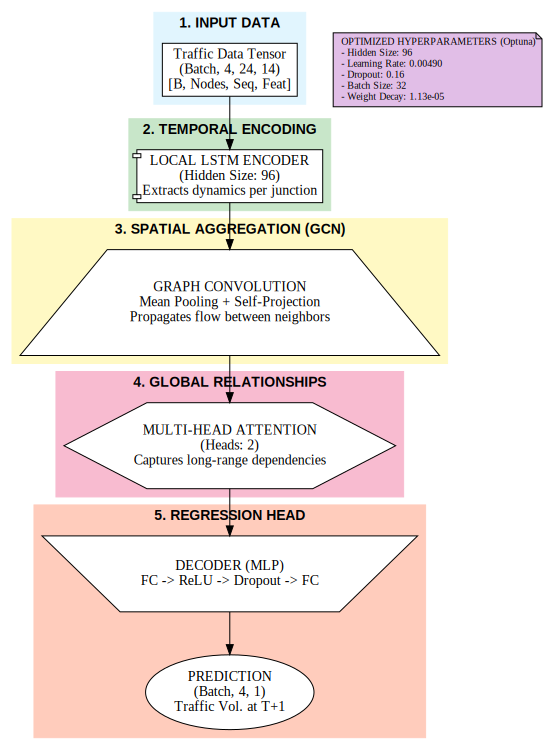

In [49]:
import graphviz
from IPython.display import display

# Configuration des couleurs et styles
COLORS = {
    'input': '#E1F5FE',
    'temporal': '#C8E6C9',
    'spatial': '#FFF9C4',
    'attention': '#F8BBD0',
    'output': '#FFCCBC',
    'params': '#E1BEE7',
    'border': '#455A64'
}

def create_architecture_diag():
    dot = graphviz.Digraph(comment='TrafficGNN Architecture', format='png')
    dot.attr(rankdir='TB', nodesep='0.5', ranksep='0.6', fontname='Helvetica', splines='ortho')

    # --- INPUT LAYER ---
    with dot.subgraph(name='cluster_0') as c:
        c.attr(label='1. INPUT DATA', style='filled', color=COLORS['input'], fontname='Helvetica-Bold')
        c.node('IN', 'Traffic Data Tensor\n(Batch, 4, 24, 14)\n[B, Nodes, Seq, Feat]', shape='box', style='filled', fillcolor='white')

    # --- TEMPORAL LAYER ---
    with dot.subgraph(name='cluster_1') as c:
        c.attr(label='2. TEMPORAL ENCODING', style='filled', color=COLORS['temporal'], fontname='Helvetica-Bold')
        c.node('LSTM', f'LOCAL LSTM ENCODER\n(Hidden Size: {best_params_p3["hidden_size"]})\nExtracts dynamics per junction', shape='component', style='filled', fillcolor='white')

    # --- SPATIAL LAYER ---
    with dot.subgraph(name='cluster_2') as c:
        c.attr(label='3. SPATIAL AGGREGATION (GCN)', style='filled', color=COLORS['spatial'], fontname='Helvetica-Bold')
        c.node('GCN', 'GRAPH CONVOLUTION\nMean Pooling + Self-Projection\nPropagates flow between neighbors', shape='trapezium', style='filled', fillcolor='white')

    # --- ATTENTION LAYER ---
    with dot.subgraph(name='cluster_3') as c:
        c.attr(label='4. GLOBAL RELATIONSHIPS', style='filled', color=COLORS['attention'], fontname='Helvetica-Bold')
        c.node('MHA', f'MULTI-HEAD ATTENTION\n(Heads: {best_params_p3["num_heads"]})\nCaptures long-range dependencies', shape='hexagon', style='filled', fillcolor='white')

    # --- OUTPUT LAYER ---
    with dot.subgraph(name='cluster_4') as c:
        c.attr(label='5. REGRESSION HEAD', style='filled', color=COLORS['output'], fontname='Helvetica-Bold')
        c.node('MLP', 'DECODER (MLP)\nFC -> ReLU -> Dropout -> FC', shape='invtrapezium', style='filled', fillcolor='white')
        c.node('OUT', 'PREDICTION\n(Batch, 4, 1)\nTraffic Vol. at T+1', shape='ellipse', style='filled', fillcolor='white')

    # --- HYPERPARAMETERS BOX ---
    params_text = f"OPTIMIZED HYPERPARAMETERS (Optuna)\l- Hidden Size: {best_params_p3['hidden_size']}\l- Learning Rate: {best_params_p3['lr']:.5f}\l- Dropout: {best_params_p3['dropout']:.2f}\l- Batch Size: {best_params_p3['batch_size']}\l- Weight Decay: {best_params_p3['weight_decay']:.2e}\l"
    dot.node('PARAMS', params_text, shape='note', style='filled', fillcolor=COLORS['params'], fontsize='10')

    # Connections
    dot.edge('IN', 'LSTM')
    dot.edge('LSTM', 'GCN')
    dot.edge('GCN', 'MHA')
    dot.edge('MHA', 'MLP')
    dot.edge('MLP', 'OUT')

    return dot

# Affichage
diagram = create_architecture_diag()
display(diagram)

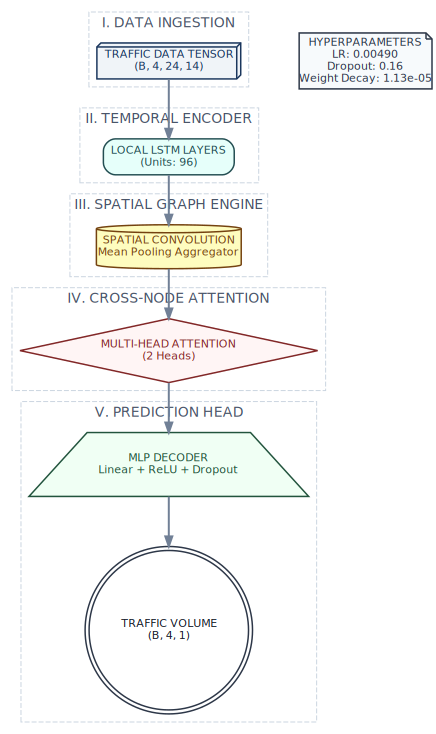


--- Téléchargement du design ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
import graphviz
from IPython.display import display
from google.colab import files

# Configuration de style professionnelle améliorée
STYLE = {
    'input': {'fill': '#f0f4f8', 'stroke': '#1a365d', 'font': '#1a365d'},
    'temporal': {'fill': '#e6fffa', 'stroke': '#234e52', 'font': '#234e52'},
    'spatial': {'fill': '#fefcbf', 'stroke': '#744210', 'font': '#744210'},
    'attention': {'fill': '#fff5f5', 'stroke': '#822727', 'font': '#822727'},
    'output': {'fill': '#f0fff4', 'stroke': '#22543d', 'font': '#22543d'},
    'params': {'fill': '#f7fafc', 'stroke': '#2d3748', 'font': '#2d3748'}
}

def create_styled_architecture():
    dot = graphviz.Digraph(comment='TrafficGNN Professional Architecture', format='png')
    dot.attr(rankdir='TB', nodesep='0.8', ranksep='0.7', fontname='Segoe UI,Helvetica,Arial', compound='true')
    dot.attr('node', fontname='Segoe UI,Helvetica,Arial', fontsize='11', penwidth='1.5')

    # 1. INPUT
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='I. DATA INGESTION', color='#cbd5e0', fontcolor='#4a5568', style='dashed', penwidth='1')
        c.node('IN', 'TRAFFIC DATA TENSOR\n(B, 4, 24, 14)', shape='box3d', style='filled',
               fillcolor=STYLE['input']['fill'], color=STYLE['input']['stroke'], fontcolor=STYLE['input']['font'])

    # 2. TEMPORAL
    with dot.subgraph(name='cluster_temp') as c:
        c.attr(label='II. TEMPORAL ENCODER', color='#cbd5e0', fontcolor='#4a5568', style='dashed')
        c.node('LSTM', f'LOCAL LSTM LAYERS\n(Units: {best_params_p3["hidden_size"]})', shape='rect', style='filled,rounded',
               fillcolor=STYLE['temporal']['fill'], color=STYLE['temporal']['stroke'], fontcolor=STYLE['temporal']['font'])

    # 3. SPATIAL
    with dot.subgraph(name='cluster_spatial') as c:
        c.attr(label='III. SPATIAL GRAPH ENGINE', color='#cbd5e0', fontcolor='#4a5568', style='dashed')
        c.node('GCN', 'SPATIAL CONVOLUTION\nMean Pooling Aggregator', shape='cylinder', style='filled',
               fillcolor=STYLE['spatial']['fill'], color=STYLE['spatial']['stroke'], fontcolor=STYLE['spatial']['font'])

    # 4. ATTENTION
    with dot.subgraph(name='cluster_attn') as c:
        c.attr(label='IV. CROSS-NODE ATTENTION', color='#cbd5e0', fontcolor='#4a5568', style='dashed')
        c.node('MHA', f'MULTI-HEAD ATTENTION\n({best_params_p3["num_heads"]} Heads)', shape='diamond', style='filled',
               fillcolor=STYLE['attention']['fill'], color=STYLE['attention']['stroke'], fontcolor=STYLE['attention']['font'])

    # 5. OUTPUT
    with dot.subgraph(name='cluster_output') as c:
        c.attr(label='V. PREDICTION HEAD', color='#cbd5e0', fontcolor='#4a5568', style='dashed')
        c.node('MLP', 'MLP DECODER\nLinear + ReLU + Dropout', shape='trapezium', style='filled',
               fillcolor=STYLE['output']['fill'], color=STYLE['output']['stroke'], fontcolor=STYLE['output']['font'])
        c.node('OUT', 'TRAFFIC VOLUME\n(B, 4, 1)', shape='doublecircle', style='filled',
               fillcolor='#ffffff', color='#2d3748', fontcolor='#1a202c')

    # PARAMS NOTE
    params_label = (f"HYPERPARAMETERS\n"
                    f"LR: {best_params_p3['lr']:.5f}\n"
                    f"Dropout: {best_params_p3['dropout']:.2f}\n"
                    f"Weight Decay: {best_params_p3['weight_decay']:.2e}")
    dot.node('NOTE', params_label, shape='note', style='filled',
             fillcolor=STYLE['params']['fill'], color=STYLE['params']['stroke'], fontcolor=STYLE['params']['font'])

    # Edges with smooth lines
    dot.edge('IN', 'LSTM', penwidth='2', color='#718096')
    dot.edge('LSTM', 'GCN', penwidth='2', color='#718096')
    dot.edge('GCN', 'MHA', penwidth='2', color='#718096')
    dot.edge('MHA', 'MLP', penwidth='2', color='#718096')
    dot.edge('MLP', 'OUT', penwidth='2', color='#718096')

    return dot

# Génération et affichage
diagram_final = create_styled_architecture()
diagram_final.render('traffic_gnn_architecture_v2', cleanup=True)
display(diagram_final)

# Proposer le téléchargement
print("\n--- Téléchargement du design ---")
files.download('traffic_gnn_architecture_v2.png')